<a href="https://colab.research.google.com/github/AnujikaSasindi/sri-lanka-tourism-sentiment-analysis/blob/Main/F_Sentiment_Prediction_Model_6_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Installations**

In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import evaluate

## **Dataset**

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx')

print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Saving balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx to balanced_cleaned_dataset_1_(sentiment + attarction category).xlsx
Shape of dataset: (7164, 11)

Column names:
['Location_Name', 'Located_City', 'Location_Type', 'Title', 'Text', 'Review_Text', 'Rating', 'Sentiment', 'Cluster_Text', 'Attraction_Cluster', 'Attraction_Category']

First 5 rows:


,Location_Name,Located_City,Location_Type,Title,Text,Review_Text,Rating,Sentiment,Cluster_Text,Attraction_Cluster,Attraction_Category
0,Handunugoda Tea Estate,Ahangama,Farms,Wonderful Experience,This was our third tea factory tour during our...,Wonderful Experience This was our third tea fa...,5,Positive,Handunugoda Tea Estate Farms Wonderful Experie...,4,Tea Plantations & Factory Tours
1,Glenloch Tea Factory,Katukitula,Farms,In-TEA-resting,A worth visit for everyone who drinks tea. Gui...,In-TEA-resting A worth visit for everyone who ...,4,Positive,Glenloch Tea Factory Farms In-TEA-resting A wo...,4,Tea Plantations & Factory Tours
2,Handunugoda Tea Estate,Ahangama,Farms,"The best tea experience, great history","Hidden away in a beautiful stretch of green, t...","The best tea experience, great history Hidden ...",5,Positive,Handunugoda Tea Estate Farms The best tea expe...,4,Tea Plantations & Factory Tours
3,Bluefield Tea Gardens,Nuwara Eliya,Farms,Informative tour,We really enjoyed our tour at the Bluefield te...,Informative tour We really enjoyed our tour at...,5,Positive,Bluefield Tea Gardens Farms Informative tour W...,4,Tea Plantations & Factory Tours
4,Ceylon Tea Museum,Kandy,Museums,Under appreciated - well worth,We spend a few enjoyable hours here. It is aro...,Under appreciated - well worth We spend a few ...,4,Positive,Ceylon Tea Museum Museums Under appreciated - ...,4,Tea Plantations & Factory Tours


In [ ]:
df = df[["Title", "Text", "Sentiment"]]

df = df.dropna(subset=["Title", "Text", "Sentiment"])

df = df.drop_duplicates()

df["Combined_Text"] = (
    df["Title"].astype(str).str.strip() + " " +
    df["Text"].astype(str).str.strip()
)


df = df[["Combined_Text", "Sentiment"]]

df.reset_index(drop=True, inplace=True)

df.head()

,Combined_Text,Sentiment
0,Wonderful Experience This was our third tea fa...,Positive
1,In-TEA-resting A worth visit for everyone who ...,Positive
2,"The best tea experience, great history Hidden ...",Positive
3,Informative tour We really enjoyed our tour at...,Positive
4,Under appreciated - well worth We spend a few ...,Positive


In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Sentiment"])

print(label_encoder.classes_)

['Negative' 'Neutral' 'Positive']


## **Train / Validation / Test Split**

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1765,
    random_state=42,
    stratify=train_df["label"]
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

5012
1075
1075


In [ ]:
train_dataset = Dataset.from_pandas(train_df[["Combined_Text","label"]])
val_dataset = Dataset.from_pandas(val_df[["Combined_Text","label"]])
test_dataset = Dataset.from_pandas(test_df[["Combined_Text","label"]])

## **Metric Function**

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


## **Weighted Version Function**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

print(class_weights)

[2.08572618 1.10275028 0.61968348]


In [ ]:
import torch

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedTrainer(Trainer):

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

## **Random Over-Sampling Function**

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X = train_df["Combined_Text"].values.reshape(-1, 1)
y = train_df["label"]

X_res, y_res = ros.fit_resample(X, y)

print("Before:", np.bincount(y))
print("After:", np.bincount(y_res))

Before: [ 801 1515 2696]
After: [2696 2696 2696]


In [ ]:
train_df_balanced = pd.DataFrame({
    "Combined_Text": X_res.flatten(),
    "label": y_res
}).reset_index(drop=True)

In [ ]:
from datasets import Dataset, DatasetDict

# final_train_dataset = Dataset.from_pandas(train_df_balanced)
# test_dataset = Dataset.from_pandas(test_df[["Combined_Text", "label"]])
ds = DatasetDict({
    'train': Dataset.from_pandas(train_df_balanced),
    'validation': Dataset.from_pandas(val_df[['Combined_Text', 'label']]),
    'test': Dataset.from_pandas(test_df[['Combined_Text', 'label']])
})

## **Fine-tuning BERT**

### **Baseline**

In [ ]:
BERT_MODEL_NAME = "bert-base-uncased"

In [ ]:
from transformers import AutoTokenizer, AutoConfig

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

In [ ]:
def bert_tokenize(batch):
    return bert_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
bert_train_tokenized = train_dataset.map(bert_tokenize, batched=True)
bert_val_tokenized = val_dataset.map(bert_tokenize, batched=True)
bert_test_tokenized = test_dataset.map(bert_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator_bert = DataCollatorWithPadding(tokenizer=bert_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

bert_training_args = TrainingArguments(
    output_dir="/content/BERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train_tokenized,
    eval_dataset=bert_val_tokenized,
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics
)

In [ ]:
bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.559845,0.495487,0.796279,0.787744,0.754314,0.766414
2,0.433256,0.508152,0.794419,0.758867,0.755579,0.757087
3,0.315412,0.548848,0.800000,0.777129,0.754463,0.764537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=942, training_loss=0.4625733531457856, metrics={'train_runtime': 398.7453, 'train_samples_per_second': 37.708, 'train_steps_per_second': 2.362, 'total_flos': 989043337239552.0, 'train_loss': 0.4625733531457856, 'epoch': 3.0})

In [ ]:
history_bert = bert_trainer.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_bert = []
val_loss_per_epoch_bert = []
epochs_bert = []

current_epoch = 1
epoch_losses_bert = []

for log in history_bert:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_bert.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_bert) > 0:

            avg_train_loss_bert = (
                sum(epoch_losses_bert)
                / len(epoch_losses_bert)
            )

            train_loss_per_epoch_bert.append(avg_train_loss_bert)
            val_loss_per_epoch_bert.append(log["eval_loss"])
            epochs_bert.append(int(log["epoch"]))

            epoch_losses_bert = []

In [ ]:
loss_df_bert = pd.DataFrame({
    "Epoch": epochs_bert,
    "Training Loss": train_loss_per_epoch_bert,
    "Validation Loss": val_loss_per_epoch_bert
})

print(loss_df_bert)

   Epoch  Training Loss  Validation Loss
0      1       0.656316         0.495487
1      2       0.443124         0.508152
2      3       0.319543         0.548848


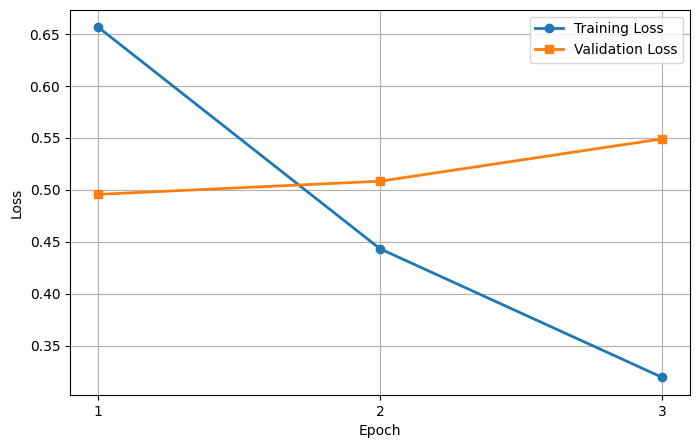

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_bert,
    train_loss_per_epoch_bert,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_bert,
    val_loss_per_epoch_bert,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_bert)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_bert = []
val_f1_bert = []

for log in history_bert:

    if "eval_f1" in log:
        if len(val_epochs_bert) == epochs:
            break
        val_epochs_bert.append(int(log["epoch"]))
        val_f1_bert.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_bert = pd.DataFrame({
    "Epoch": val_epochs_bert,
    "Validation Macro F1": val_f1_bert
})

print(f1_df_bert)

   Epoch  Validation Macro F1
0      1             0.766414
1      2             0.757087
2      3             0.764537


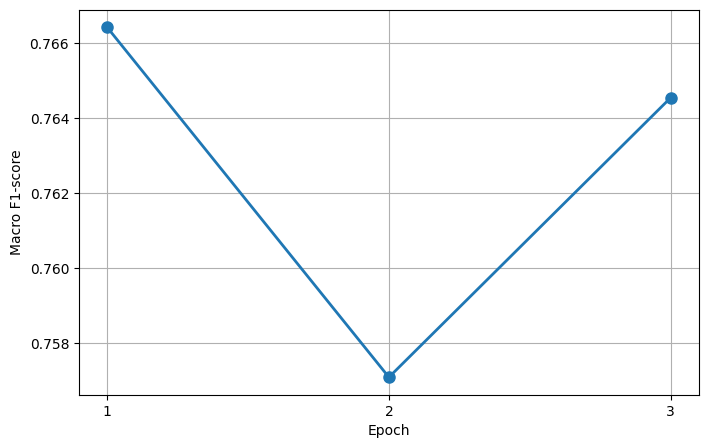

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_bert,
    val_f1_bert,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_bert)

plt.grid(True)

plt.show()

In [ ]:
bert_results = bert_trainer.evaluate(bert_test_tokenized)

bert_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.315412,0.514675,3,0.773023,0.758311,0.735016,0.744660


{'eval_loss': 0.5146749019622803,
 'eval_accuracy': 0.7730232558139535,
 'eval_precision': 0.7583105031813995,
 'eval_recall': 0.7350164757052985,
 'eval_f1': 0.7446598049309027}

In [ ]:
predictions_bert = bert_trainer.predict(bert_test_tokenized)

y_pred_bert = np.argmax(predictions_bert.predictions, axis=1)

y_true_bert = predictions_bert.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.79      0.67      0.73       172
     Neutral       0.62      0.67      0.64       325
    Positive       0.86      0.86      0.86       578

    accuracy                           0.77      1075
   macro avg       0.76      0.74      0.74      1075
weighted avg       0.78      0.77      0.77      1075



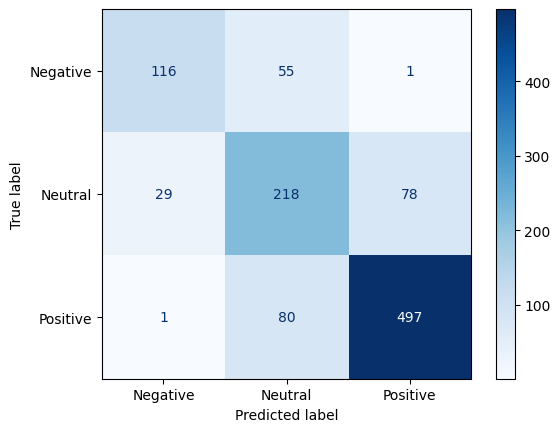

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

bert_trainer.save_model("/content/BERT_Final")

bert_tokenizer.save_pretrained("/content/BERT_Final")

### **Class-weighted version**

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model_cw = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

bert_training_args_cw = TrainingArguments(
    output_dir="/content/BERT_CW",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

bert_trainer_cw = WeightedTrainer(
    model=bert_model_cw,
    args=bert_training_args_cw,
    train_dataset=bert_train_tokenized,
    eval_dataset=bert_val_tokenized,
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
bert_trainer_cw.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.597698,0.575693,0.769302,0.748104,0.753926,0.747278
2,0.515083,0.596503,0.772093,0.727180,0.743621,0.734122
3,0.318858,0.670397,0.787907,0.758961,0.751934,0.754920


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=942, training_loss=0.5296783639620317, metrics={'train_runtime': 433.5651, 'train_samples_per_second': 34.68, 'train_steps_per_second': 2.173, 'total_flos': 989043337239552.0, 'train_loss': 0.5296783639620317, 'epoch': 3.0})

In [ ]:
history_bert_cw = bert_trainer_cw.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_bert_cw = []
val_loss_per_epoch_bert_cw = []
epochs_bert_cw = []

current_epoch = 1
epoch_losses_bert_cw = []

for log in history_bert_cw:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_bert_cw.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_bert_cw) > 0:

            avg_train_loss_bert_cw = (
                sum(epoch_losses_bert_cw)
                / len(epoch_losses_bert_cw)
            )

            train_loss_per_epoch_bert_cw.append(avg_train_loss_bert_cw)
            val_loss_per_epoch_bert_cw.append(log["eval_loss"])
            epochs_bert_cw.append(int(log["epoch"]))

            epoch_losses_bert_cw = []

In [ ]:
loss_df_bert_cw = pd.DataFrame({
    "Epoch": epochs_bert_cw,
    "Training Loss": train_loss_per_epoch_bert_cw,
    "Validation Loss": val_loss_per_epoch_bert_cw
})

print(loss_df_bert_cw)

   Epoch  Training Loss  Validation Loss
0      1       0.781518         0.575693
1      2       0.495142         0.596503
2      3       0.347280         0.670397


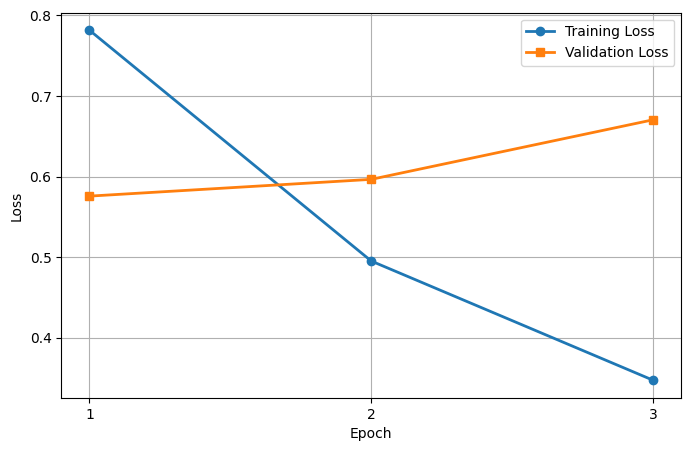

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_bert_cw,
    train_loss_per_epoch_bert_cw,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_bert_cw,
    val_loss_per_epoch_bert_cw,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_bert_cw)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_bert_cw = []
val_f1_bert_cw = []

for log in history_bert_cw:

    if "eval_f1" in log:
        if len(val_epochs_bert_cw) == epochs:
            break

        val_epochs_bert_cw.append(int(log["epoch"]))
        val_f1_bert_cw.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_bert_cw = pd.DataFrame({
    "Epoch": val_epochs_bert_cw,
    "Validation Macro F1": val_f1_bert_cw
})

print(f1_df_bert_cw)

   Epoch  Validation Macro F1
0      1             0.747278
1      2             0.734122
2      3             0.754920


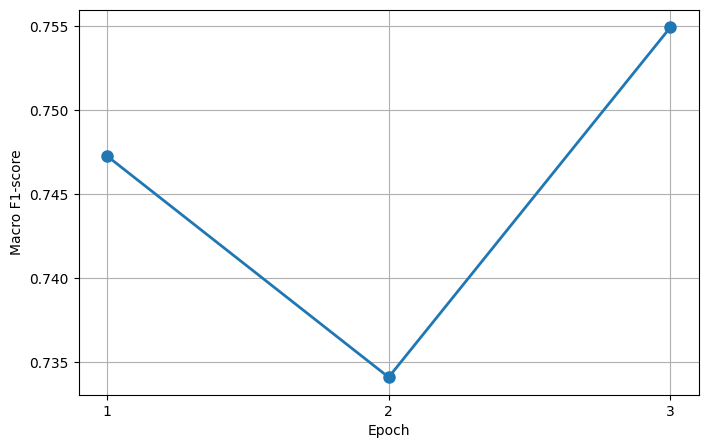

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_bert_cw,
    val_f1_bert_cw,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_bert_cw)

plt.grid(True)

plt.show()

In [ ]:
bert_results_cw = bert_trainer_cw.evaluate(bert_test_tokenized)

bert_results_cw

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.318858,0.641860,3,0.777674,0.749668,0.753366,0.751463


{'eval_loss': 0.6418595314025879,
 'eval_accuracy': 0.7776744186046511,
 'eval_precision': 0.7496676585457985,
 'eval_recall': 0.7533664291771638,
 'eval_f1': 0.7514627687362628}

In [ ]:
predictions_bert_cw = bert_trainer_cw.predict(bert_test_tokenized)

y_pred_bert_cw = np.argmax(predictions_bert_cw.predictions, axis=1)

y_true_bert_cw = predictions_bert_cw.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_bert_cw,
    y_pred_bert_cw,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.74      0.76      0.75       172
     Neutral       0.63      0.65      0.64       325
    Positive       0.87      0.86      0.86       578

    accuracy                           0.78      1075
   macro avg       0.75      0.75      0.75      1075
weighted avg       0.78      0.78      0.78      1075



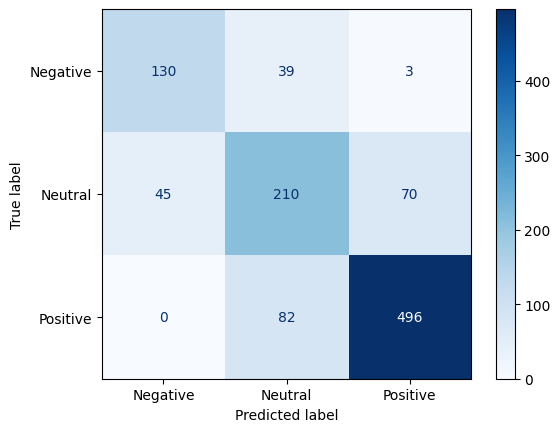

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_bert_cw = confusion_matrix(y_true_bert_cw, y_pred_bert_cw)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert_cw,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

bert_trainer.save_model("/content/BERT_CW_Final")

bert_tokenizer.save_pretrained("/content/BERT_CW_Final")

### **ROS**

In [ ]:
tokenized_bert = ds.map(bert_tokenize, batched=True)

Map:   0%|          | 0/8088 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

bert_model_ros = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

bert_training_args_ros = TrainingArguments(
    output_dir="/content/BERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

bert_trainer_ros = Trainer(
    model=bert_model_ros,
    args=bert_training_args_ros,
    train_dataset=tokenized_bert['train'],
    eval_dataset=tokenized_bert['validation'],
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics
)

In [ ]:
bert_trainer_ros.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.429123,0.521500,0.788837,0.759160,0.750294,0.754523
2,0.265625,0.653062,0.782326,0.747884,0.739466,0.743477
3,0.139447,0.867549,0.774884,0.737636,0.734895,0.736154


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=1518, training_loss=0.33416348452310474, metrics={'train_runtime': 683.2299, 'train_samples_per_second': 35.514, 'train_steps_per_second': 2.222, 'total_flos': 1596045991938048.0, 'train_loss': 0.33416348452310474, 'epoch': 3.0})

In [ ]:
history_bert_ros = bert_trainer_ros.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_bert_ros = []
val_loss_per_epoch_bert_ros = []
epochs_bert_ros = []

current_epoch = 1
epoch_losses_bert_ros = []

for log in history_bert_ros:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_bert_ros.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_bert_ros) > 0:

            avg_train_loss_bert_ros = (
                sum(epoch_losses_bert_ros)
                / len(epoch_losses_bert_ros)
            )

            train_loss_per_epoch_bert_ros.append(avg_train_loss_bert_ros)
            val_loss_per_epoch_bert_ros.append(log["eval_loss"])
            epochs_bert_ros.append(int(log["epoch"]))

            epoch_losses_bert_ros = []

In [ ]:
loss_df_bert_ros = pd.DataFrame({
    "Epoch": epochs_bert_ros,
    "Training Loss": train_loss_per_epoch_bert_ros,
    "Validation Loss": val_loss_per_epoch_bert_ros
})

print(loss_df_bert_ros)

   Epoch  Training Loss  Validation Loss
0      1       0.596750         0.521500
1      2       0.278434         0.653062
2      3       0.136951         0.867549


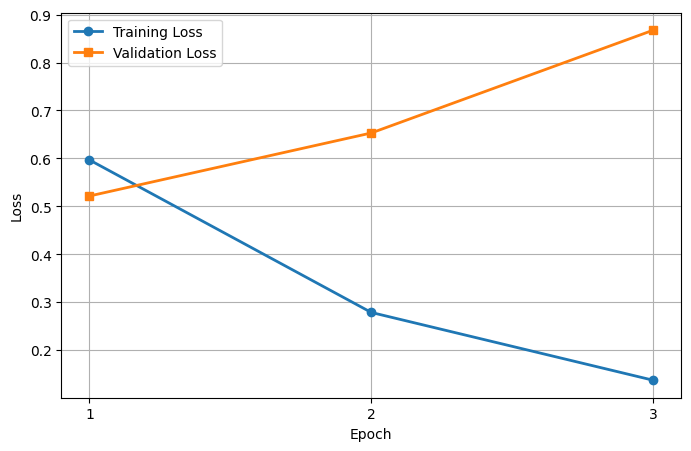

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_bert_ros,
    train_loss_per_epoch_bert_ros,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_bert_ros,
    val_loss_per_epoch_bert_ros,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_bert_ros)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_bert_ros = []
val_f1_bert_ros = []

for log in history_bert_ros:

    if "eval_f1" in log:
        if len(val_epochs_bert_ros) == epochs:
            break
        val_epochs_bert_ros.append(int(log["epoch"]))
        val_f1_bert_ros.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_bert_ros = pd.DataFrame({
    "Epoch": val_epochs_bert_ros,
    "Validation Macro F1": val_f1_bert_ros
})

print(f1_df_bert_ros)

   Epoch  Validation Macro F1
0      1             0.754523
1      2             0.743477
2      3             0.736154


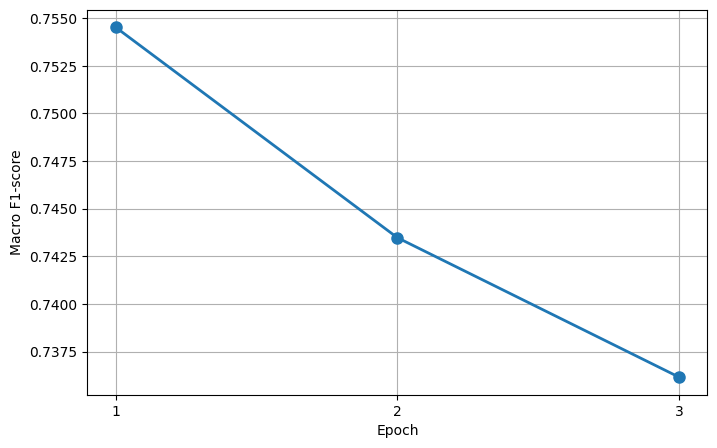

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_bert_ros,
    val_f1_bert_ros,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_bert_ros)

plt.grid(True)

plt.show()

In [ ]:
bert_results_ros = bert_trainer_ros.evaluate(tokenized_bert['test'])

bert_results_ros

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.139447,0.535075,3,0.783256,0.760208,0.757725,0.758942


{'eval_loss': 0.5350754857063293,
 'eval_accuracy': 0.7832558139534884,
 'eval_precision': 0.7602080452531967,
 'eval_recall': 0.7577245163034171,
 'eval_f1': 0.758942039705675}

In [ ]:
predictions_bert_ros = bert_trainer_ros.predict(tokenized_bert['test'])

y_pred_bert_ros = np.argmax(predictions_bert_ros.predictions, axis=1)

y_true_bert_ros = predictions_bert_ros.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_bert_ros,
    y_pred_bert_ros,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.77      0.76      0.76       172
     Neutral       0.65      0.65      0.65       325
    Positive       0.87      0.87      0.87       578

    accuracy                           0.78      1075
   macro avg       0.76      0.76      0.76      1075
weighted avg       0.78      0.78      0.78      1075



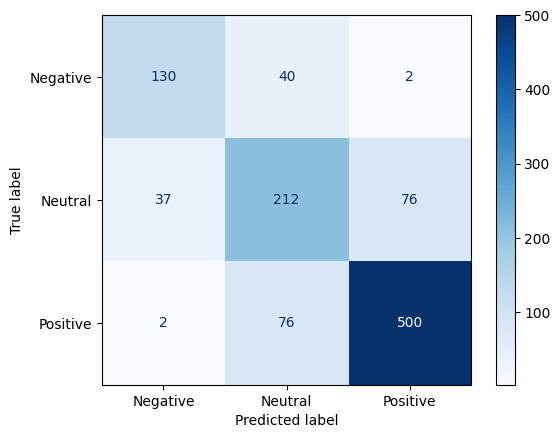

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_bert_ros = confusion_matrix(y_true_bert_ros, y_pred_bert_ros)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bert_ros,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

bert_trainer.save_model("/content/BERT_Final")

bert_tokenizer.save_pretrained("/content/BERT_Final")

## **Fine-tuning DistilBERT**

### **Baseline**

In [ ]:
DistilBERT_MODEL_NAME = "distilbert-base-uncased"

In [ ]:
from transformers import AutoTokenizer

distilbert_tokenizer = AutoTokenizer.from_pretrained(DistilBERT_MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def distilbert_tokenize(batch):
    return distilbert_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
distilbert_train_tokenized = train_dataset.map(distilbert_tokenize, batched=True)
distilbert_val_tokenized = val_dataset.map(distilbert_tokenize, batched=True)
distilbert_test_tokenized = test_dataset.map(distilbert_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator_distilbert = DataCollatorWithPadding(tokenizer=distilbert_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

distilbert_model = AutoModelForSequenceClassification.from_pretrained(
    DistilBERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

distilbert_training_args = TrainingArguments(
    output_dir="/content/DistilBERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_train_tokenized,
    eval_dataset=distilbert_val_tokenized,
    data_collator=data_collator_distilbert,
    compute_metrics=compute_metrics
)

In [ ]:
distilbert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.565808,0.531461,0.778605,0.767660,0.717971,0.733559
2,0.446830,0.543299,0.772093,0.734839,0.722347,0.727218
3,0.365118,0.551537,0.780465,0.753046,0.732853,0.741779


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.483167072263746, metrics={'train_runtime': 228.3112, 'train_samples_per_second': 65.857, 'train_steps_per_second': 4.126, 'total_flos': 497953831689216.0, 'train_loss': 0.483167072263746, 'epoch': 3.0})

In [ ]:
history_distilbert = distilbert_trainer.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_distilbert = []
val_loss_per_epoch_distilbert = []
epochs_distilbert = []

current_epoch = 1
epoch_losses_distilbert = []

for log in history_distilbert:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_distilbert.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_distilbert) > 0:

            avg_train_loss_distilbert = (
                sum(epoch_losses_distilbert)
                / len(epoch_losses_distilbert)
            )

            train_loss_per_epoch_distilbert.append(avg_train_loss_distilbert)
            val_loss_per_epoch_distilbert.append(log["eval_loss"])
            epochs_distilbert.append(int(log["epoch"]))

            epoch_losses_distilbert = []

In [ ]:
loss_df_distilbert = pd.DataFrame({
    "Epoch": epochs_distilbert,
    "Training Loss": train_loss_per_epoch_distilbert,
    "Validation Loss": val_loss_per_epoch_distilbert
})

print(loss_df_distilbert)

   Epoch  Training Loss  Validation Loss
0      1       0.660004         0.531461
1      2       0.457360         0.543299
2      3       0.357519         0.551537


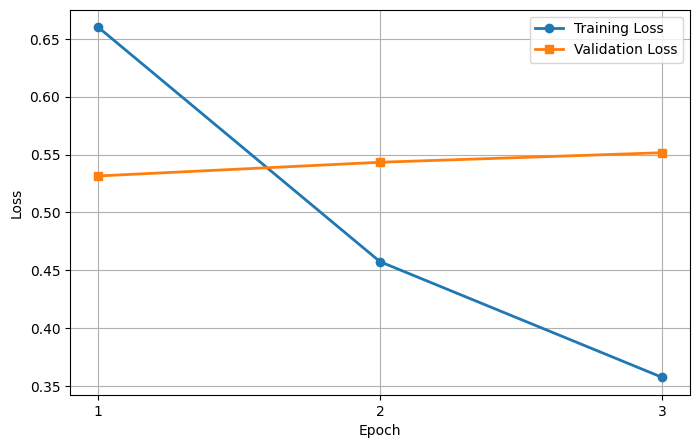

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_distilbert,
    train_loss_per_epoch_distilbert,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_distilbert,
    val_loss_per_epoch_distilbert,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_distilbert)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_distilbert = []
val_f1_distilbert = []

for log in history_distilbert:

    if "eval_f1" in log:
        if len(val_epochs_distilbert) == epochs:
            break
        val_epochs_distilbert.append(int(log["epoch"]))
        val_f1_distilbert.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_distilbert = pd.DataFrame({
    "Epoch": val_epochs_distilbert,
    "Validation Macro F1": val_f1_distilbert
})

print(f1_df_distilbert)

   Epoch  Validation Macro F1
0      1             0.733559
1      2             0.727218
2      3             0.741779


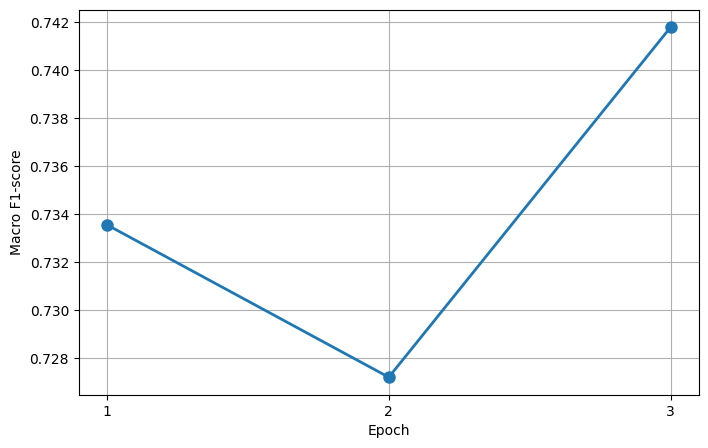

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_distilbert,
    val_f1_distilbert,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_distilbert)

plt.grid(True)

plt.show()

In [ ]:
distilbert_results = distilbert_trainer.evaluate(distilbert_test_tokenized)

distilbert_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.365118,0.565550,3,0.780465,0.753373,0.739731,0.745758


{'eval_loss': 0.5655504465103149,
 'eval_accuracy': 0.7804651162790698,
 'eval_precision': 0.7533732981463034,
 'eval_recall': 0.7397313335520465,
 'eval_f1': 0.7457583795162276}

In [ ]:
predictions_distilbert = distilbert_trainer.predict(distilbert_test_tokenized)

y_pred_distilbert = np.argmax(predictions_distilbert.predictions, axis=1)

y_true_distilbert = predictions_distilbert.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_distilbert,
    y_pred_distilbert,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.75      0.72      0.73       172
     Neutral       0.66      0.61      0.63       325
    Positive       0.85      0.90      0.87       578

    accuracy                           0.78      1075
   macro avg       0.75      0.74      0.75      1075
weighted avg       0.78      0.78      0.78      1075



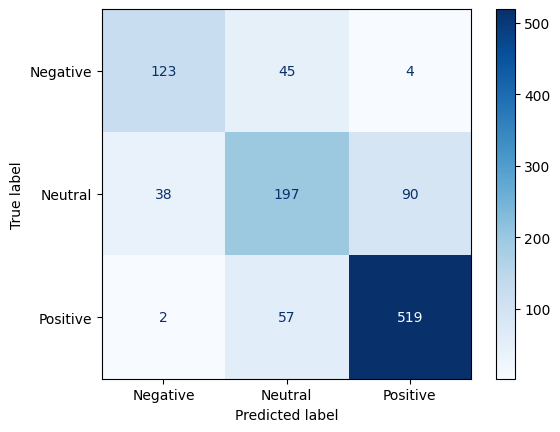

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_distilbert = confusion_matrix(y_true_distilbert, y_pred_distilbert)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_distilbert,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

distilbert_trainer.save_model("/content/DistilBERT_Final")

distilbert_tokenizer.save_pretrained("/content/DistilBERT_Final")

### **Class-weighted version**

In [ ]:
from transformers import AutoModelForSequenceClassification

distilbert_model_cw = AutoModelForSequenceClassification.from_pretrained(
    DistilBERT_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

distilbert_training_args_cw = TrainingArguments(
    output_dir="/content/DistilBERT_CW",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

distilbert_trainer_cw = WeightedTrainer(
    model=distilbert_model_cw,
    args=distilbert_training_args_cw,
    train_dataset=distilbert_train_tokenized,
    eval_dataset=distilbert_val_tokenized,
    data_collator=data_collator_distilbert,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
distilbert_trainer_cw.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.613280,0.602599,0.760930,0.737258,0.741943,0.735933
2,0.497846,0.611128,0.760000,0.718305,0.740164,0.727580
3,0.370228,0.663580,0.768372,0.736886,0.733031,0.734159


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.5324606672720291, metrics={'train_runtime': 210.271, 'train_samples_per_second': 71.508, 'train_steps_per_second': 4.48, 'total_flos': 497953831689216.0, 'train_loss': 0.5324606672720291, 'epoch': 3.0})

In [ ]:
history_distilbert_cw = distilbert_trainer_cw.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_distilbert_cw = []
val_loss_per_epoch_distilbert_cw = []
epochs_distilbert_cw = []

current_epoch = 1
epoch_losses_distilbert_cw = []

for log in history_distilbert_cw:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_distilbert_cw.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_distilbert_cw) > 0:

            avg_train_loss_distilbert_cw = (
                sum(epoch_losses_distilbert_cw)
                / len(epoch_losses_distilbert_cw)
            )

            train_loss_per_epoch_distilbert_cw.append(avg_train_loss_distilbert_cw)
            val_loss_per_epoch_distilbert_cw.append(log["eval_loss"])
            epochs_distilbert_cw.append(int(log["epoch"]))

            epoch_losses_distilbert_cw = []

In [ ]:
loss_df_distilbert_cw = pd.DataFrame({
    "Epoch": epochs_distilbert_cw,
    "Training Loss": train_loss_per_epoch_distilbert_cw,
    "Validation Loss": val_loss_per_epoch_distilbert_cw
})

print(loss_df_distilbert_cw)

   Epoch  Training Loss  Validation Loss
0      1       0.731669         0.602599
1      2       0.503780         0.611128
2      3       0.388799         0.663580


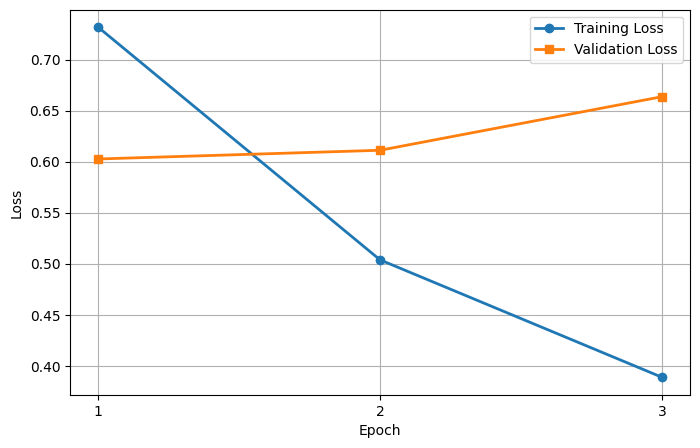

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_distilbert_cw,
    train_loss_per_epoch_distilbert_cw,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_distilbert_cw,
    val_loss_per_epoch_distilbert_cw,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_distilbert_cw)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_distilbert_cw = []
val_f1_distilbert_cw = []

for log in history_distilbert_cw:

    if "eval_f1" in log:
        if len(val_epochs_distilbert_cw) == epochs:
            break

        val_epochs_distilbert_cw.append(int(log["epoch"]))
        val_f1_distilbert_cw.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_distilbert_cw = pd.DataFrame({
    "Epoch": val_epochs_distilbert_cw,
    "Validation Macro F1": val_f1_distilbert_cw
})

print(f1_df_distilbert_cw)

   Epoch  Validation Macro F1
0      1             0.735933
1      2             0.727580
2      3             0.734159


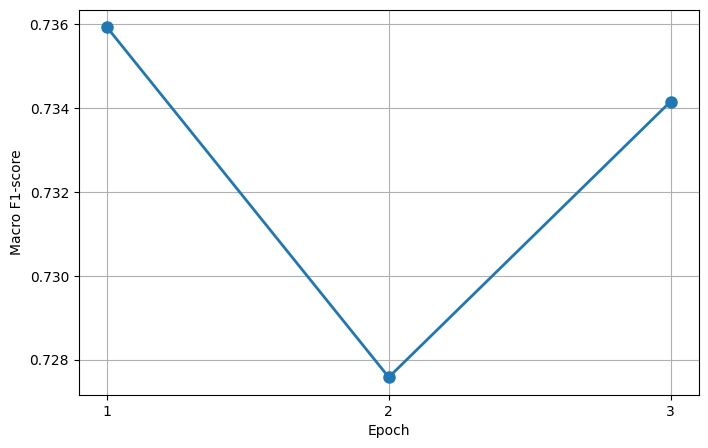

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_distilbert_cw,
    val_f1_distilbert_cw,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_distilbert_cw)

plt.grid(True)

plt.show()

In [ ]:
distilbert_results_cw = distilbert_trainer_cw.evaluate(distilbert_test_tokenized)

distilbert_results_cw

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.370228,0.587088,3,0.753488,0.728138,0.745570,0.734199


{'eval_loss': 0.5870879292488098,
 'eval_accuracy': 0.7534883720930232,
 'eval_precision': 0.7281382005881158,
 'eval_recall': 0.7455696962569096,
 'eval_f1': 0.7341994046645013}

In [ ]:
predictions_distilbert_cw = distilbert_trainer_cw.predict(distilbert_test_tokenized)

y_pred_distilbert_cw = np.argmax(predictions_distilbert_cw.predictions, axis=1)

y_true_distilbert_cw = predictions_distilbert_cw.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_distilbert_cw,
    y_pred_distilbert_cw,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.70      0.76      0.73       172
     Neutral       0.59      0.69      0.64       325
    Positive       0.89      0.79      0.84       578

    accuracy                           0.75      1075
   macro avg       0.73      0.75      0.73      1075
weighted avg       0.77      0.75      0.76      1075



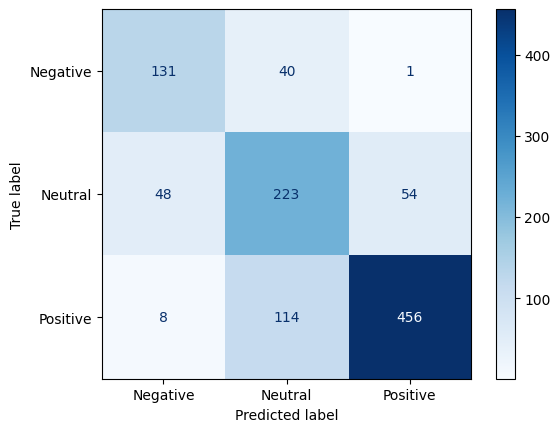

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_distilbert_cw = confusion_matrix(y_true_distilbert_cw, y_pred_distilbert_cw)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_distilbert_cw,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

distilbert_trainer.save_model("/content/DistilBERT_Final")

distilbert_tokenizer.save_pretrained("/content/DistilBERT_Final")

### **ROS**

In [ ]:
tokenized_distilbert = ds.map(distilbert_tokenize, batched=True)

Map:   0%|          | 0/8088 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

distilbert_model_ros = AutoModelForSequenceClassification.from_pretrained(
    DistilBERT_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

distilbert_training_args_ros = TrainingArguments(
    output_dir="/content/DistilBERT",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

distilbert_trainer_ros = Trainer(
    model=distilbert_model_ros,
    args=distilbert_training_args_ros,
    train_dataset=tokenized_distilbert['train'],
    eval_dataset=tokenized_distilbert['validation'],
    data_collator=data_collator_distilbert,
    compute_metrics=compute_metrics
)

In [ ]:
distilbert_trainer_ros.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.449693,0.566111,0.768372,0.729769,0.751683,0.739134
2,0.321283,0.613412,0.778605,0.746684,0.733524,0.739585
3,0.217188,0.727783,0.773953,0.740676,0.732436,0.736091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1518, training_loss=0.3705197462765439, metrics={'train_runtime': 363.9029, 'train_samples_per_second': 66.677, 'train_steps_per_second': 4.171, 'total_flos': 803561570371584.0, 'train_loss': 0.3705197462765439, 'epoch': 3.0})

In [ ]:
history_distilbert_ros = distilbert_trainer_ros.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_distilbert_ros = []
val_loss_per_epoch_distilbert_ros = []
epochs_distilbert_ros = []

current_epoch = 1
epoch_losses_distilbert_ros = []

for log in history_distilbert_ros:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_distilbert_ros.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_distilbert_ros) > 0:

            avg_train_loss_distilbert_ros = (
                sum(epoch_losses_distilbert_ros)
                / len(epoch_losses_distilbert_ros)
            )

            train_loss_per_epoch_distilbert_ros.append(avg_train_loss_distilbert_ros)
            val_loss_per_epoch_distilbert_ros.append(log["eval_loss"])
            epochs_distilbert_ros.append(int(log["epoch"]))

            epoch_losses_distilbert_ros = []

In [ ]:
loss_df_distilbert_ros = pd.DataFrame({
    "Epoch": epochs_distilbert_ros,
    "Training Loss": train_loss_per_epoch_distilbert_ros,
    "Validation Loss": val_loss_per_epoch_distilbert_ros
})

print(loss_df_distilbert_ros)

   Epoch  Training Loss  Validation Loss
0      1       0.605869         0.566111
1      2       0.321939         0.613412
2      3       0.191811         0.727783


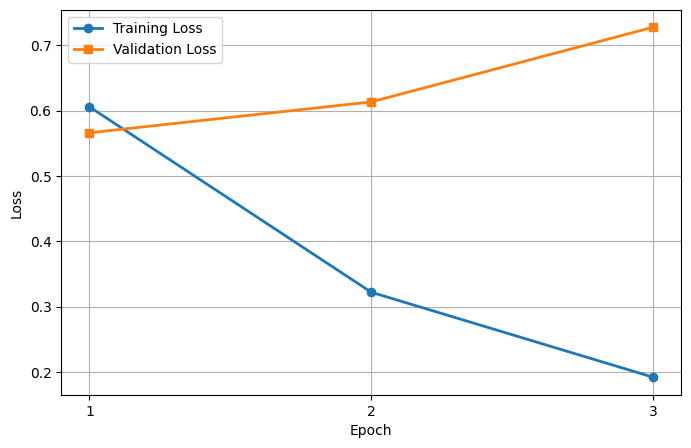

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_distilbert_ros,
    train_loss_per_epoch_distilbert_ros,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_distilbert_ros,
    val_loss_per_epoch_distilbert_ros,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_bert_ros)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_distilbert_ros = []
val_f1_distilbert_ros = []

for log in history_distilbert_ros:

    if "eval_f1" in log:
        if len(val_epochs_distilbert_ros) == epochs:
            break
        val_epochs_distilbert_ros.append(int(log["epoch"]))
        val_f1_distilbert_ros.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_distilbert_ros = pd.DataFrame({
    "Epoch": val_epochs_distilbert_ros,
    "Validation Macro F1": val_f1_distilbert_ros
})

print(f1_df_distilbert_ros)

   Epoch  Validation Macro F1
0      1             0.739134
1      2             0.739585
2      3             0.736091


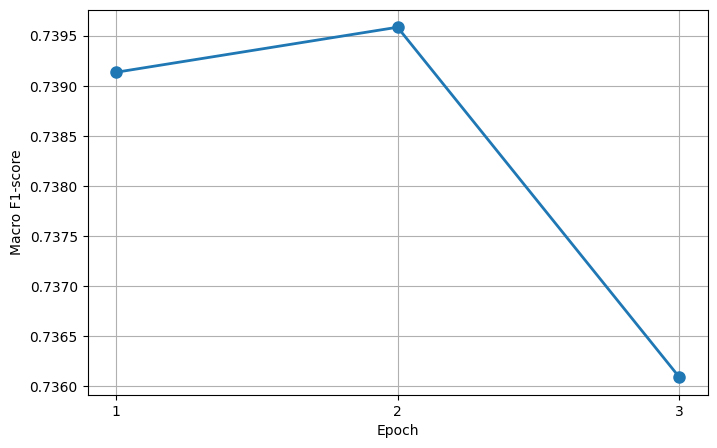

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_distilbert_ros,
    val_f1_distilbert_ros,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_distilbert_ros)

plt.grid(True)

plt.show()

In [ ]:
distilbert_results_ros = distilbert_trainer_ros.evaluate(tokenized_distilbert['test'])

distilbert_results_ros

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.217188,0.637486,3,0.765581,0.732135,0.730041,0.731037


{'eval_loss': 0.6374863982200623,
 'eval_accuracy': 0.7655813953488372,
 'eval_precision': 0.7321354853925203,
 'eval_recall': 0.730040709538577,
 'eval_f1': 0.7310368440673388}

In [ ]:
predictions_distilbert_ros = distilbert_trainer_ros.predict(tokenized_distilbert['test'])

y_pred_distilbert_ros = np.argmax(predictions_distilbert_ros.predictions, axis=1)

y_true_distilbert_ros = predictions_distilbert_ros.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_distilbert_ros,
    y_pred_distilbert_ros,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.71      0.71      0.71       172
     Neutral       0.63      0.61      0.62       325
    Positive       0.86      0.87      0.86       578

    accuracy                           0.77      1075
   macro avg       0.73      0.73      0.73      1075
weighted avg       0.76      0.77      0.76      1075



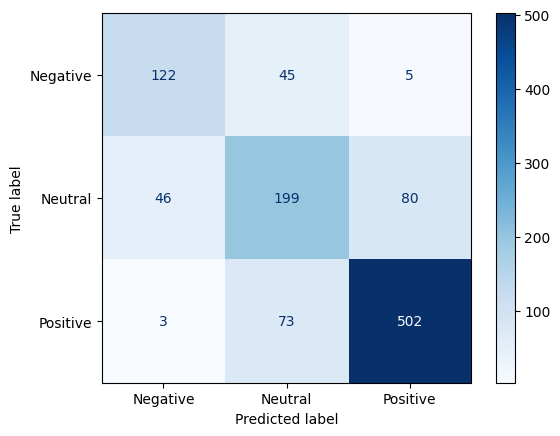

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_distilbert_ros = confusion_matrix(y_true_distilbert_ros, y_pred_distilbert_ros)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_distilbert_ros,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

distilbert_trainer.save_model("/content/DistilBERT_Final")

distilbert_tokenizer.save_pretrained("/content/DistilBERT_Final")

## **Fine-tuning RoBERTa**

### **Baseline**

In [ ]:
RoBERTa_MODEL_NAME = "roberta-base"

In [ ]:
from transformers import AutoTokenizer

roberta_tokenizer = AutoTokenizer.from_pretrained(RoBERTa_MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
roberta_train_tokenized = train_dataset.map(roberta_tokenize, batched=True)
roberta_val_tokenized = val_dataset.map(roberta_tokenize, batched=True)
roberta_test_tokenized = test_dataset.map(roberta_tokenize, batched=True)

Map:   0%|          | 0/5012 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator_roberta = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

roberta_training_args = TrainingArguments(
    output_dir="/content/RoBERTa",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_tokenized,
    eval_dataset=roberta_val_tokenized,
    data_collator=data_collator_roberta,
    compute_metrics=compute_metrics
)

In [ ]:
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.544019,0.494082,0.794419,0.783324,0.753624,0.764479
2,0.462933,0.484838,0.795349,0.759423,0.763527,0.758427
3,0.319232,0.501766,0.810233,0.786017,0.770828,0.777544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.4719631778206795, metrics={'train_runtime': 527.982, 'train_samples_per_second': 28.478, 'train_steps_per_second': 1.784, 'total_flos': 989043337239552.0, 'train_loss': 0.4719631778206795, 'epoch': 3.0})

In [ ]:
history_roberta = roberta_trainer.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_roberta = []
val_loss_per_epoch_roberta = []
epochs_roberta = []

current_epoch = 1
epoch_losses_roberta = []

for log in history_roberta:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_roberta.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_roberta) > 0:

            avg_train_loss_roberta = (
                sum(epoch_losses_roberta)
                / len(epoch_losses_roberta)
            )

            train_loss_per_epoch_roberta.append(avg_train_loss_roberta)
            val_loss_per_epoch_roberta.append(log["eval_loss"])
            epochs_roberta.append(int(log["epoch"]))

            epoch_losses_roberta = []

In [ ]:
loss_df_roberta = pd.DataFrame({
    "Epoch": epochs_roberta,
    "Training Loss": train_loss_per_epoch_roberta,
    "Validation Loss": val_loss_per_epoch_roberta
})

print(loss_df_roberta)

   Epoch  Training Loss  Validation Loss
0      1       0.644642         0.494082
1      2       0.452729         0.484838
2      3       0.343529         0.501766


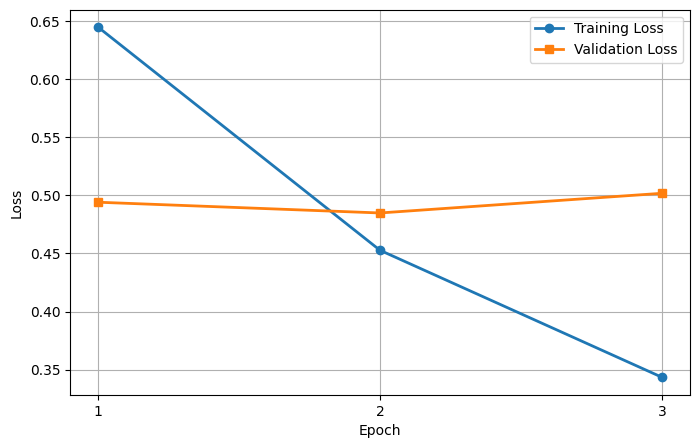

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_roberta,
    train_loss_per_epoch_roberta,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_roberta,
    val_loss_per_epoch_roberta,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_roberta)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_roberta = []
val_f1_roberta = []

for log in history_roberta:

    if "eval_f1" in log:
        if len(val_epochs_roberta) == epochs:
            break
        val_epochs_roberta.append(int(log["epoch"]))
        val_f1_roberta.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_roberta = pd.DataFrame({
    "Epoch": val_epochs_roberta,
    "Validation Macro F1": val_f1_roberta
})

print(f1_df_roberta)

   Epoch  Validation Macro F1
0      1             0.764479
1      2             0.758427
2      3             0.777544


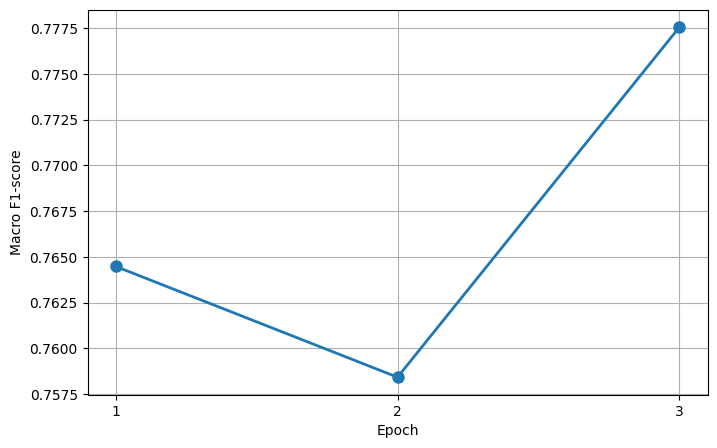

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_roberta,
    val_f1_roberta,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_roberta)

plt.grid(True)

plt.show()

In [ ]:
roberta_results = roberta_trainer.evaluate(roberta_test_tokenized)

roberta_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.319232,0.507488,3,0.807442,0.785122,0.769996,0.776838


{'eval_loss': 0.5074875354766846,
 'eval_accuracy': 0.8074418604651162,
 'eval_precision': 0.7851223980928754,
 'eval_recall': 0.7699961828359672,
 'eval_f1': 0.7768383968086474}

In [ ]:
predictions_roberta = roberta_trainer.predict(roberta_test_tokenized)

y_pred_roberta = np.argmax(predictions_roberta.predictions, axis=1)

y_true_roberta = predictions_roberta.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_roberta,
    y_pred_roberta,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.79      0.74      0.77       172
     Neutral       0.70      0.65      0.68       325
    Positive       0.87      0.91      0.89       578

    accuracy                           0.81      1075
   macro avg       0.79      0.77      0.78      1075
weighted avg       0.80      0.81      0.80      1075



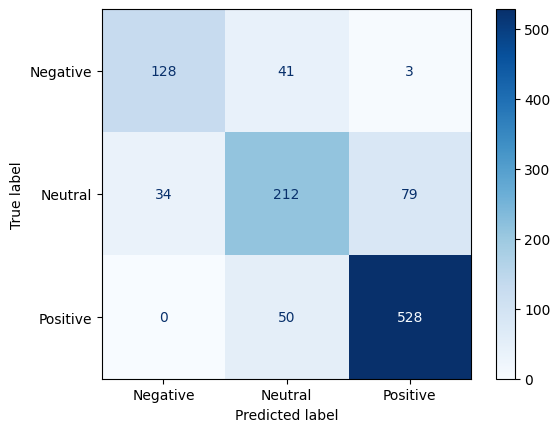

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_roberta = confusion_matrix(y_true_roberta, y_pred_roberta)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_roberta,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

roberta_trainer.save_model("/content/RoBERTa_Final")

roberta_tokenizer.save_pretrained("/content/RoBERTa_Final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_Final/tokenizer_config.json',
 '/content/RoBERTa_Final/tokenizer.json')

### **Class-weighted Version**

In [ ]:
from transformers import AutoModelForSequenceClassification

roberta_model_cw = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

roberta_training_args_cw = TrainingArguments(
    output_dir="/content/RoBERTa_CW",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

roberta_trainer_cw = WeightedTrainer(
    model=roberta_model_cw,
    args=roberta_training_args_cw,
    train_dataset=roberta_train_tokenized,
    eval_dataset=roberta_val_tokenized,
    data_collator=data_collator_roberta,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
roberta_trainer_cw.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.575399,0.581217,0.788837,0.774970,0.761040,0.765032
2,0.495087,0.594247,0.778605,0.736755,0.758157,0.743701
3,0.330355,0.633297,0.800000,0.771658,0.768989,0.770298


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=942, training_loss=0.5127941615515706, metrics={'train_runtime': 452.4646, 'train_samples_per_second': 33.231, 'train_steps_per_second': 2.082, 'total_flos': 989043337239552.0, 'train_loss': 0.5127941615515706, 'epoch': 3.0})

In [ ]:
history_roberta_cw = roberta_trainer_cw.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_roberta_cw = []
val_loss_per_epoch_roberta_cw = []
epochs_roberta_cw = []

current_epoch = 1
epoch_losses_roberta_cw = []

for log in history_roberta_cw:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_roberta_cw.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_roberta_cw) > 0:

            avg_train_loss_roberta_cw = (
                sum(epoch_losses_roberta_cw)
                / len(epoch_losses_roberta_cw)
            )

            train_loss_per_epoch_roberta_cw.append(avg_train_loss_roberta_cw)
            val_loss_per_epoch_roberta_cw.append(log["eval_loss"])
            epochs_roberta_cw.append(int(log["epoch"]))

            epoch_losses_roberta_cw = []

In [ ]:
loss_df_roberta_cw = pd.DataFrame({
    "Epoch": epochs_roberta_cw,
    "Training Loss": train_loss_per_epoch_roberta_cw,
    "Validation Loss": val_loss_per_epoch_roberta_cw
})

print(loss_df_roberta_cw)

   Epoch  Training Loss  Validation Loss
0      1       0.712792         0.581217
1      2       0.494528         0.594247
2      3       0.358884         0.633297


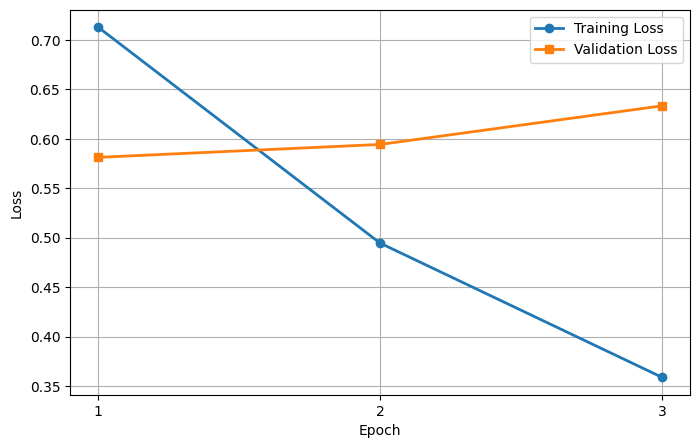

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_roberta_cw,
    train_loss_per_epoch_roberta_cw,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_roberta_cw,
    val_loss_per_epoch_roberta_cw,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_roberta_cw)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_roberta_cw = []
val_f1_roberta_cw = []

for log in history_roberta_cw:

    if "eval_f1" in log:
        if len(val_epochs_roberta_cw) == epochs:
            break

        val_epochs_roberta_cw.append(int(log["epoch"]))
        val_f1_roberta_cw.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_roberta_cw = pd.DataFrame({
    "Epoch": val_epochs_roberta_cw,
    "Validation Macro F1": val_f1_roberta_cw
})

print(f1_df_roberta_cw)

   Epoch  Validation Macro F1
0      1             0.765032
1      2             0.743701
2      3             0.770298


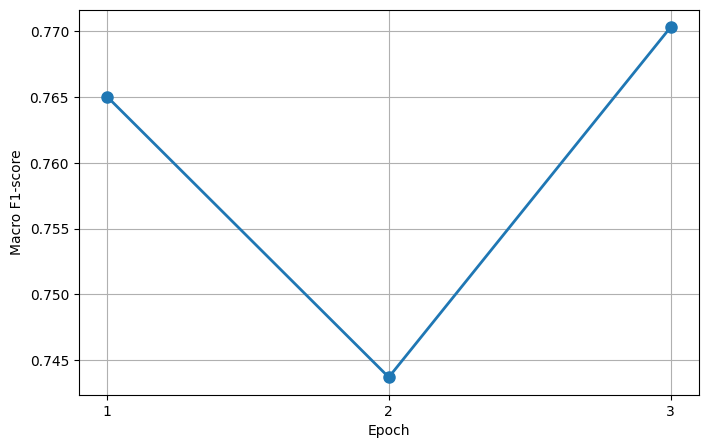

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_roberta_cw,
    val_f1_roberta_cw,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_roberta_cw)

plt.grid(True)

plt.show()

In [ ]:
roberta_results_cw = roberta_trainer_cw.evaluate(roberta_test_tokenized)

roberta_results_cw

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.330355,0.617248,3,0.797209,0.762713,0.769127,0.765313


{'eval_loss': 0.6172477602958679,
 'eval_accuracy': 0.7972093023255814,
 'eval_precision': 0.7627129960919315,
 'eval_recall': 0.7691265297026945,
 'eval_f1': 0.7653129465217959}

In [ ]:
predictions_roberta_cw = roberta_trainer_cw.predict(roberta_test_tokenized)

y_pred_roberta_cw = np.argmax(predictions_roberta_cw.predictions, axis=1)

y_true_roberta_cw = predictions_roberta_cw.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_roberta_cw,
    y_pred_roberta_cw,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.73      0.78      0.75       172
     Neutral       0.68      0.63      0.66       325
    Positive       0.88      0.89      0.89       578

    accuracy                           0.80      1075
   macro avg       0.76      0.77      0.77      1075
weighted avg       0.79      0.80      0.80      1075



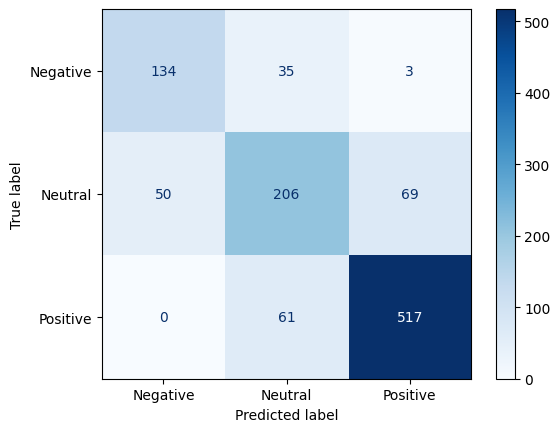

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_roberta_cw = confusion_matrix(y_true_roberta_cw, y_pred_roberta_cw)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_roberta_cw,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

roberta_trainer.save_model("/content/RoBERTa_Final")

roberta_tokenizer.save_pretrained("/content/RoBERTa_Final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_Final/tokenizer_config.json',
 '/content/RoBERTa_Final/tokenizer.json')

### **ROS**

In [ ]:
tokenized_roberta = ds.map(roberta_tokenize, batched=True)

Map:   0%|          | 0/8088 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

roberta_model_ros = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

roberta_training_args_ros = TrainingArguments(
    output_dir="/content/RoBERTa",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    seed=42
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

roberta_trainer_ros = Trainer(
    model=roberta_model_ros,
    args=roberta_training_args_ros,
    train_dataset=tokenized_roberta['train'],
    eval_dataset=tokenized_roberta['validation'],
    data_collator=data_collator_roberta,
    compute_metrics=compute_metrics
)

In [ ]:
roberta_trainer_ros.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.442908,0.543865,0.786977,0.760814,0.753573,0.755648
2,0.318981,0.620349,0.788837,0.756331,0.748904,0.752343
3,0.209783,0.845209,0.782326,0.746128,0.740870,0.743175


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1518, training_loss=0.37048452315123187, metrics={'train_runtime': 743.5576, 'train_samples_per_second': 32.632, 'train_steps_per_second': 2.042, 'total_flos': 1596045991938048.0, 'train_loss': 0.37048452315123187, 'epoch': 3.0})

In [ ]:
history_roberta_ros = roberta_trainer_ros.state.log_history

Training vs Validation loss

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lists to store values
train_loss_per_epoch_roberta_ros = []
val_loss_per_epoch_roberta_ros = []
epochs_roberta_ros = []

current_epoch = 1
epoch_losses_roberta_ros = []

for log in history_roberta_ros:

    # ----------------------------
    # Collect training losses
    # ----------------------------
    if "loss" in log and "eval_loss" not in log:
        epoch_losses_roberta_ros.append(log["loss"])

    # ----------------------------
    # Validation happens once/epoch
    # ----------------------------
    if "eval_loss" in log:

        if len(epoch_losses_roberta_ros) > 0:

            avg_train_loss_roberta_ros = (
                sum(epoch_losses_roberta_ros)
                / len(epoch_losses_roberta_ros)
            )

            train_loss_per_epoch_roberta_ros.append(avg_train_loss_roberta_ros)
            val_loss_per_epoch_roberta_ros.append(log["eval_loss"])
            epochs_roberta_ros.append(int(log["epoch"]))

            epoch_losses_roberta_ros = []

In [ ]:
loss_df_roberta_ros = pd.DataFrame({
    "Epoch": epochs_roberta_ros,
    "Training Loss": train_loss_per_epoch_roberta_ros,
    "Validation Loss": val_loss_per_epoch_roberta_ros
})

print(loss_df_roberta_ros)

   Epoch  Training Loss  Validation Loss
0      1       0.583354         0.543865
1      2       0.329657         0.620349
2      3       0.206020         0.845209


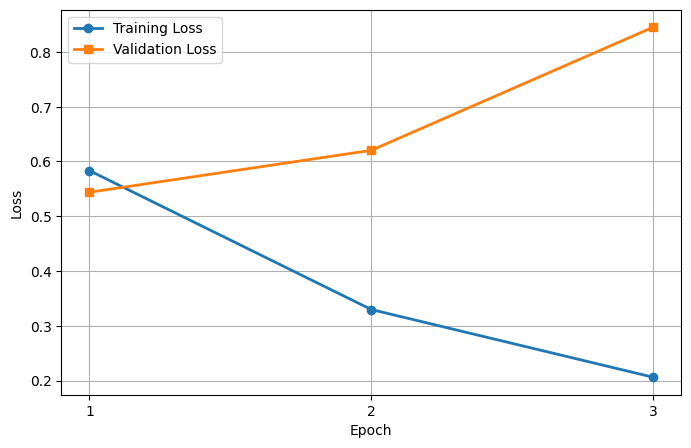

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    epochs_roberta_ros,
    train_loss_per_epoch_roberta_ros,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    epochs_roberta_ros,
    val_loss_per_epoch_roberta_ros,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

#plt.title("BERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_roberta_ros)
plt.grid(True)
plt.legend()
plt.show()

Macro-F1 score curve

In [ ]:
epochs = 3

val_epochs_roberta_ros = []
val_f1_roberta_ros = []

for log in history_roberta_ros:

    if "eval_f1" in log:
        if len(val_epochs_roberta_ros) == epochs:
            break
        val_epochs_roberta_ros.append(int(log["epoch"]))
        val_f1_roberta_ros.append(log["eval_f1"])

In [ ]:
import pandas as pd

f1_df_roberta_ros = pd.DataFrame({
    "Epoch": val_epochs_roberta_ros,
    "Validation Macro F1": val_f1_roberta_ros
})

print(f1_df_roberta_ros)

   Epoch  Validation Macro F1
0      1             0.755648
1      2             0.752343
2      3             0.743175


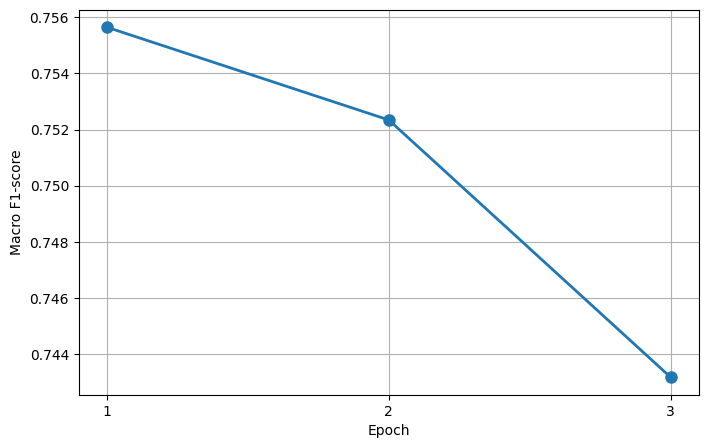

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    val_epochs_roberta_ros,
    val_f1_roberta_ros,
    marker='o',
    linewidth=2,
    markersize=8
)

#plt.title("BERT Validation Macro F1-score")

plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")

plt.xticks(val_epochs_roberta_ros)

plt.grid(True)

plt.show()

In [ ]:
roberta_results_ros = roberta_trainer_ros.evaluate(tokenized_roberta['test'])

roberta_results_ros

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.209783,0.523508,3,0.793488,0.769948,0.769441,0.769374


{'eval_loss': 0.523507833480835,
 'eval_accuracy': 0.7934883720930233,
 'eval_precision': 0.769948170194685,
 'eval_recall': 0.7694410433856801,
 'eval_f1': 0.7693736542151172}

In [ ]:
predictions_roberta_ros = roberta_trainer_ros.predict(tokenized_roberta['test'])

y_pred_roberta_ros = np.argmax(predictions_roberta_ros.predictions, axis=1)

y_true_roberta_ros = predictions_roberta_ros.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true_roberta_ros,
    y_pred_roberta_ros,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76       172
     Neutral       0.66      0.70      0.68       325
    Positive       0.89      0.86      0.87       578

    accuracy                           0.79      1075
   macro avg       0.77      0.77      0.77      1075
weighted avg       0.80      0.79      0.80      1075



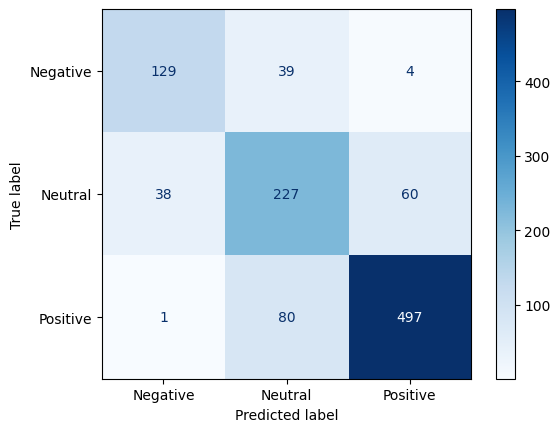

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_roberta_ros = confusion_matrix(y_true_roberta_ros, y_pred_roberta_ros)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_roberta_ros,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
# Didn't run

roberta_trainer.save_model("/content/RoBERTa_Final")

roberta_tokenizer.save_pretrained("/content/RoBERTa_Final")

## **Model Comparisons...**

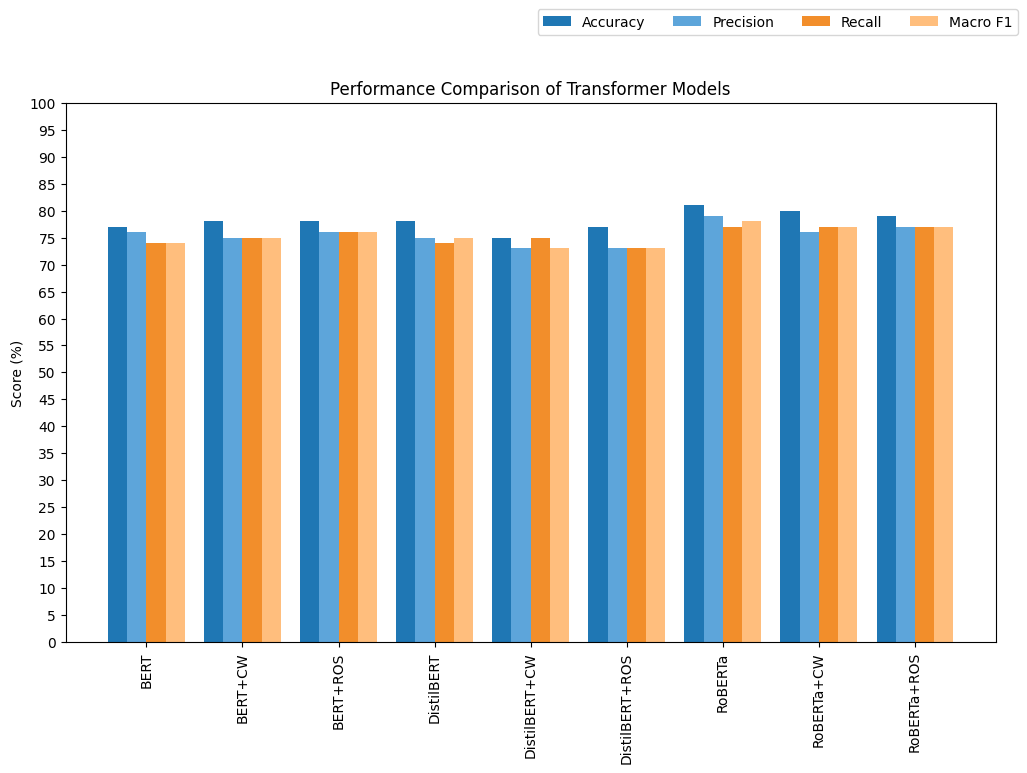

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

#colors = cm.cividis(np.linspace(0.15, 0.85, 4))

colors = [
    "#1f77b4",
    "#5DA5DA",
    "#F28E2B",
    "#FFBE7D",
]

results = pd.DataFrame({
    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS"
    ],

    "Accuracy": [
        77.0,
        78.0,
        78.0,
        78.0,
        75.0,
        77.0,
        81.0,
        80.0,
        79.0
    ],

    "Precision": [
        76.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        79.0,
        76.0,
        77.0
    ],

    "Recall": [
        74.0,
        75.0,
        76.0,
        74.0,
        75.0,
        73.0,
        77.0,
        77.0,
        77.0
    ],

    "Macro F1": [
        74.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        78.0,
        77.0,
        77.0
    ]
})

x = np.arange(len(results["Model"]))
width = 0.2

plt.figure(figsize=(12,7))

plt.bar(x-1.5*width, results["Accuracy"], width, label="Accuracy", color=colors[0]) #color=colors[0]
plt.bar(x-0.5*width, results["Precision"], width, label="Precision", color=colors[1])
plt.bar(x+0.5*width, results["Recall"], width, label="Recall", color=colors[2])
plt.bar(x+1.5*width, results["Macro F1"], width, label="Macro F1", color=colors[3])

plt.xticks(x, results["Model"], rotation=90)
plt.ylabel("Score (%)")
plt.title("Performance Comparison of Transformer Models")

plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))
plt.legend(
    loc='center left',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4
)

plt.show()

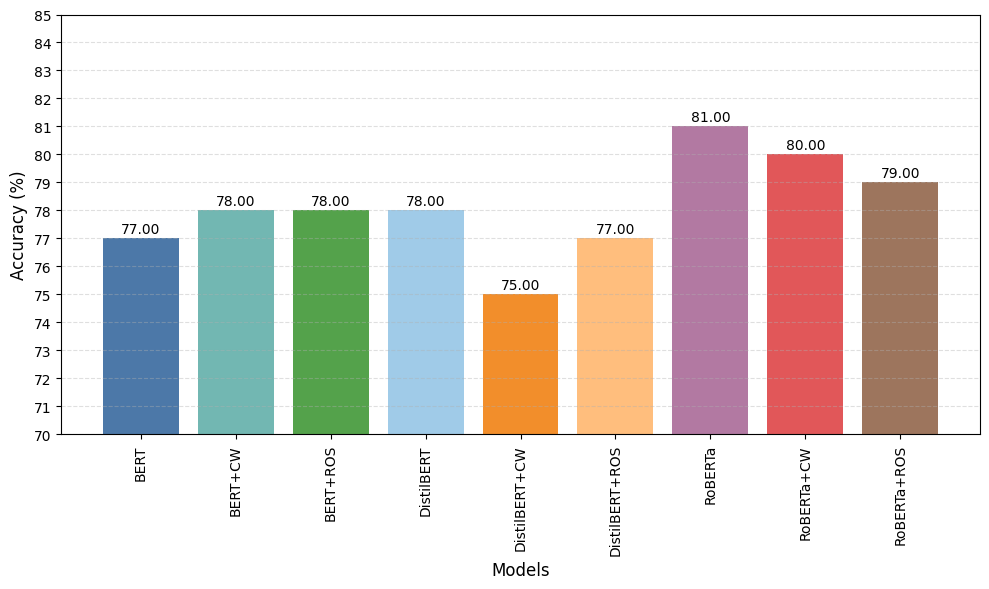

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Results
# ==============================

results = pd.DataFrame({

    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS"
    ],

    "Accuracy": [
        77.0,
        78.0,
        78.0,
        78.0,
        75.0,
        77.0,
        81.0,
        80.0,
        79.0
    ],
})

# ==============================
# Plot
# ==============================

plt.figure(figsize=(10,6))

colors = [
    "#4C78A8",  # Blue
    "#72B7B2",  # Teal
    "#54A24B",  # Green
    "#A0CBE8",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
    "#B279A2",  # Purple
    "#E15759",  # Red
    "#9D755D"   # Brown
]

bars = plt.bar(
    results["Model"],
    results["Accuracy"],
    color=colors
)

# Value labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
#plt.title("Accuracy Comparison of Transformer Models", fontsize=14)

plt.ylim(70,85)
plt.yticks(range(70,86,1))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

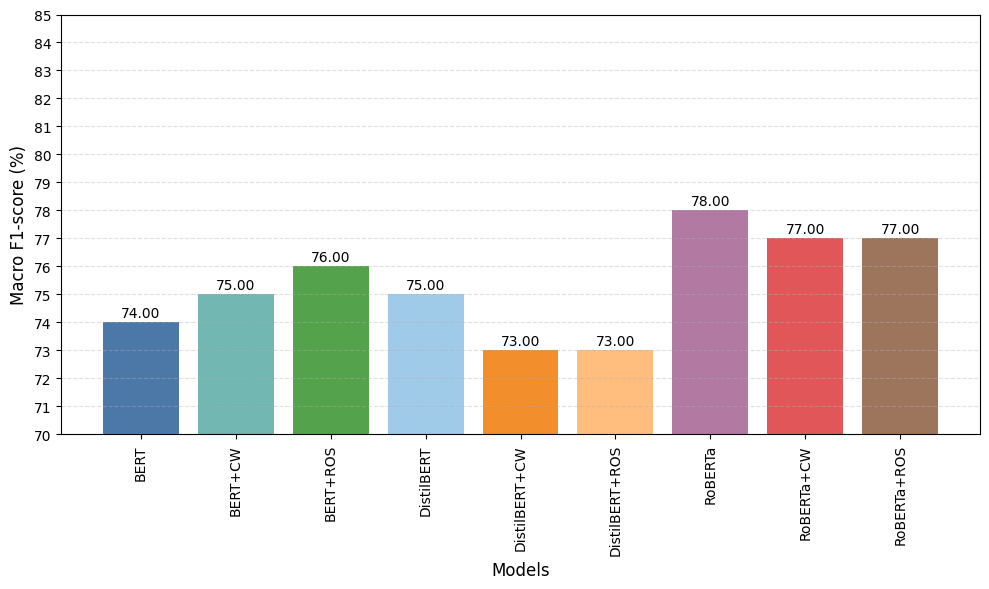

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({

    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS"
    ],

    "Macro F1": [
        74.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        78.0,
        77.0,
        77.0
    ]
})

plt.figure(figsize=(10,6))

colors = [
    "#4C78A8",  # Blue
    "#72B7B2",  # Teal
    "#54A24B",  # Green
    "#A0CBE8",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
    "#B279A2",  # Purple
    "#E15759",  # Red
    "#9D755D"   # Brown
]

bars = plt.bar(
    results["Model"],
    results["Macro F1"],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("Macro F1-score (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
#plt.title("Macro F1-score Comparison of Transformer Models", fontsize=14)

plt.ylim(70,85)
plt.yticks(range(70,86,1))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

**With Hybrid Models**

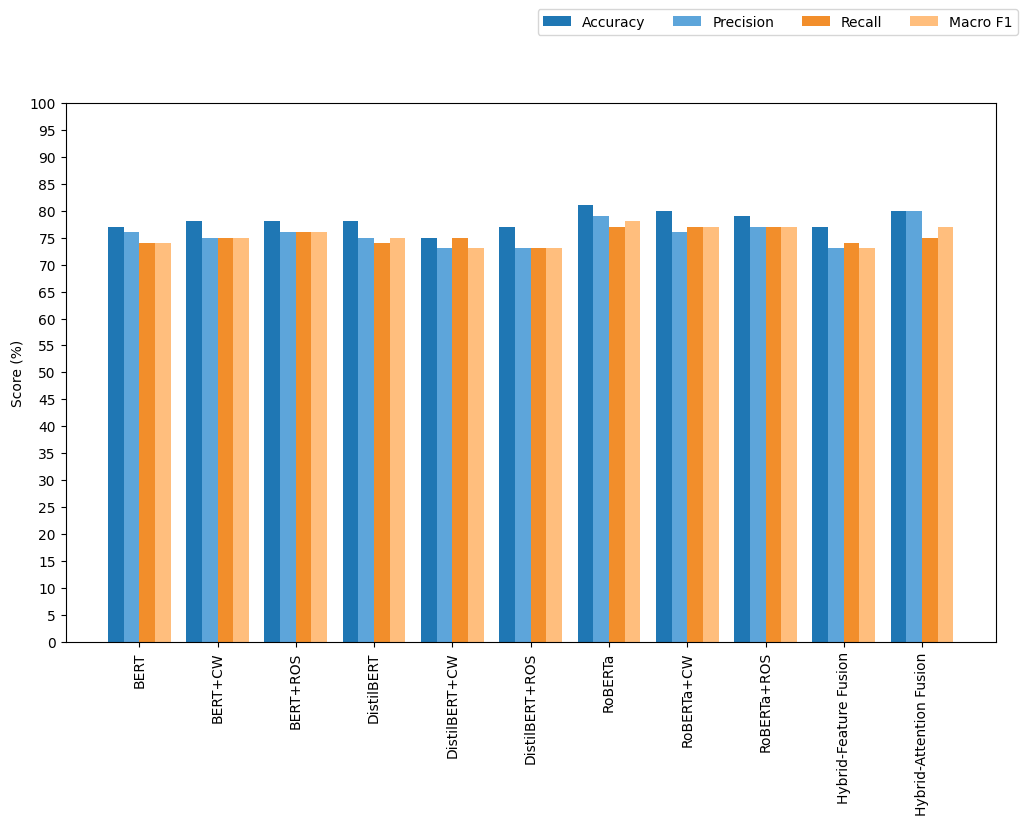

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

#colors = cm.cividis(np.linspace(0.15, 0.85, 4))

colors = [
    "#1f77b4",  # Blue
    "#5DA5DA",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
]

results = pd.DataFrame({
    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS",
        "Hybrid-Feature Fusion",
        "Hybrid-Attention Fusion"
    ],

    "Accuracy": [
        77.0,
        78.0,
        78.0,
        78.0,
        75.0,
        77.0,
        81.0,
        80.0,
        79.0,
        77.0,
        80.0
    ],

    "Precision": [
        76.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        79.0,
        76.0,
        77.0,
        73.0,
        80.0
    ],

    "Recall": [
        74.0,
        75.0,
        76.0,
        74.0,
        75.0,
        73.0,
        77.0,
        77.0,
        77.0,
        74.0,
        75.0
    ],

    "Macro F1": [
        74.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        78.0,
        77.0,
        77.0,
        73.0,
        77.0
    ]
})

x = np.arange(len(results["Model"]))
width = 0.2

plt.figure(figsize=(12,7))

plt.bar(x-1.5*width, results["Accuracy"], width, label="Accuracy", color=colors[0]) #color=colors[0]
plt.bar(x-0.5*width, results["Precision"], width, label="Precision", color=colors[1])
plt.bar(x+0.5*width, results["Recall"], width, label="Recall", color=colors[2])
plt.bar(x+1.5*width, results["Macro F1"], width, label="Macro F1", color=colors[3])

plt.xticks(x, results["Model"], rotation=90)
plt.ylabel("Score (%)")
#plt.title("Performance Comparison of Transformer Models")

plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))
plt.legend(
    loc='center left',
    bbox_to_anchor=(0.5, 1.15),
    ncol=4
)

plt.show()

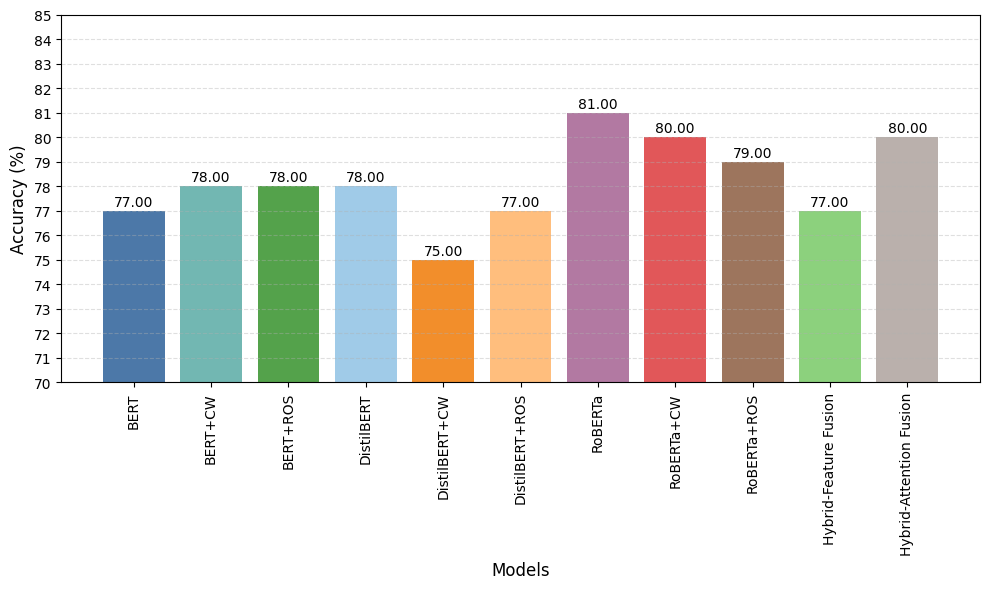

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Results
# ==============================

results = pd.DataFrame({

    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS",
        "Hybrid-Feature Fusion",
        "Hybrid-Attention Fusion"
    ],

    "Accuracy": [
        77.0,
        78.0,
        78.0,
        78.0,
        75.0,
        77.0,
        81.0,
        80.0,
        79.0,
        77.0,
        80.0
    ],
})

# ==============================
# Plot
# ==============================

plt.figure(figsize=(10,6))

colors = [
    "#4C78A8",  # Blue
    "#72B7B2",  # Teal
    "#54A24B",  # Green
    "#A0CBE8",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
    "#B279A2",  # Purple
    "#E15759",  # Red
    "#9D755D",   # Brown
    "#8CD17D",  # Light Green (NEW)
    "#BAB0AC"   # Gray (NEW)
]

bars = plt.bar(
    results["Model"],
    results["Accuracy"],
    color=colors
)

# Value labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
#plt.title("Accuracy Comparison of Transformer Models", fontsize=14)

plt.ylim(70,85)
plt.yticks(range(70,86,1))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

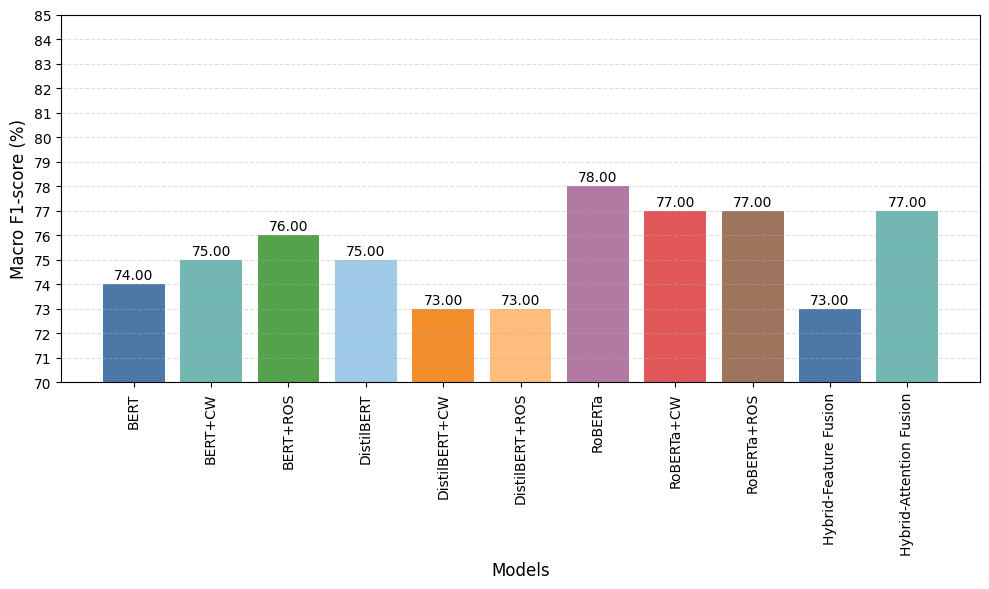

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({

    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS",
        "Hybrid-Feature Fusion",
        "Hybrid-Attention Fusion"
    ],

    "Macro F1": [
        74.0,
        75.0,
        76.0,
        75.0,
        73.0,
        73.0,
        78.0,
        77.0,
        77.0,
        73.0,
        77.0
    ]
})

plt.figure(figsize=(10,6))

colors = [
    "#4C78A8",  # Blue
    "#72B7B2",  # Teal
    "#54A24B",  # Green
    "#A0CBE8",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
    "#B279A2",  # Purple
    "#E15759",  # Red
    "#9D755D"   # Brown
]

bars = plt.bar(
    results["Model"],
    results["Macro F1"],
    color=colors
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.2,
        f"{height:.2f}",
        ha="center",
        fontsize=10
    )

plt.ylabel("Macro F1-score (%)", fontsize=12)
plt.xlabel("Models", fontsize=12)
#plt.title("Macro F1-score Comparison of Transformer Models", fontsize=14)

plt.ylim(70,85)
plt.yticks(range(70,86,1))

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

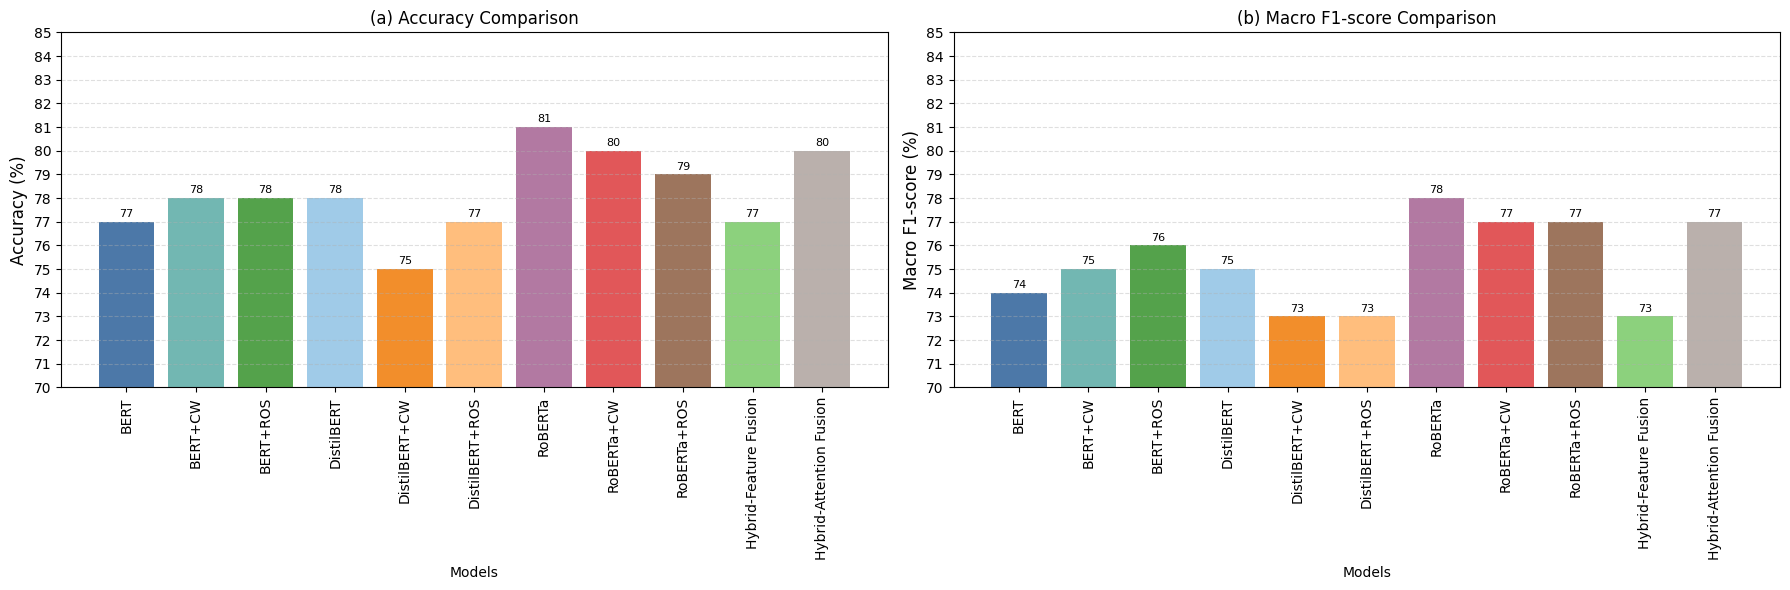

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Results
# ==============================

results = pd.DataFrame({

    "Model": [
        "BERT",
        "BERT+CW",
        "BERT+ROS",
        "DistilBERT",
        "DistilBERT+CW",
        "DistilBERT+ROS",
        "RoBERTa",
        "RoBERTa+CW",
        "RoBERTa+ROS",
        "Hybrid-Feature Fusion",
        "Hybrid-Attention Fusion"
    ],

    "Accuracy": [
        77, 78, 78,
        78, 75, 77,
        81, 80, 79,
        77, 80
    ],

    "Macro F1": [
        74, 75, 76,
        75, 73, 73,
        78, 77, 77,
        73, 77
    ]
})

# ==============================
# Colors
# ==============================

colors = [
    "#4C78A8",  # Blue
    "#72B7B2",  # Teal
    "#54A24B",  # Green
    "#A0CBE8",  # Light Blue
    "#F28E2B",  # Orange
    "#FFBE7D",  # Light Orange
    "#B279A2",  # Purple
    "#E15759",  # Red
    "#9D755D",  # Brown
    "#8CD17D",  # Light Green
    "#BAB0AC"   # Gray
]

# ==============================
# Create Subplots
# ==============================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ------------------------------
# Accuracy
# ------------------------------

bars1 = axes[0].bar(
    results["Model"],
    results["Accuracy"],
    color=colors
)

axes[0].set_ylabel("Accuracy (%)", fontsize=12)
axes[0].set_xlabel("Models")
axes[0].set_title("(a) Accuracy Comparison")

axes[0].set_ylim(70, 85)
axes[0].set_yticks(range(70, 86, 1))

axes[0].grid(axis="y", linestyle="--", alpha=0.4)

axes[0].tick_params(axis='x', rotation=90)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.0f}",
        ha='center',
        fontsize=8
    )

# ------------------------------
# Macro F1
# ------------------------------

bars2 = axes[1].bar(
    results["Model"],
    results["Macro F1"],
    color=colors
)

axes[1].set_ylabel("Macro F1-score (%)", fontsize=12)
axes[1].set_xlabel("Models")
axes[1].set_title("(b) Macro F1-score Comparison")

axes[1].set_ylim(70, 85)
axes[1].set_yticks(range(70, 86, 1))

axes[1].grid(axis="y", linestyle="--", alpha=0.4)

axes[1].tick_params(axis='x', rotation=90)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.0f}",
        ha='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    "Accuracy_MacroF1_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

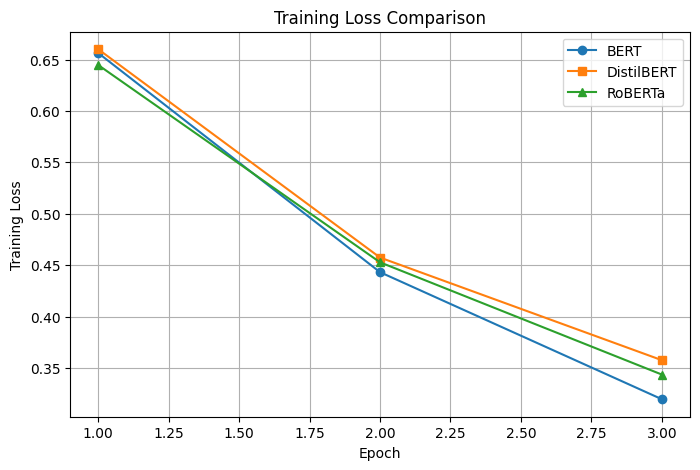

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_df_bert["Epoch"],
    loss_df_bert["Training Loss"],
    marker='o',
    label="BERT"
)

plt.plot(
    loss_df_distilbert["Epoch"],
    loss_df_distilbert["Training Loss"],
    marker='s',
    label="DistilBERT"
)

plt.plot(
    loss_df_roberta["Epoch"],
    loss_df_roberta["Training Loss"],
    marker='^',
    label="RoBERTa"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

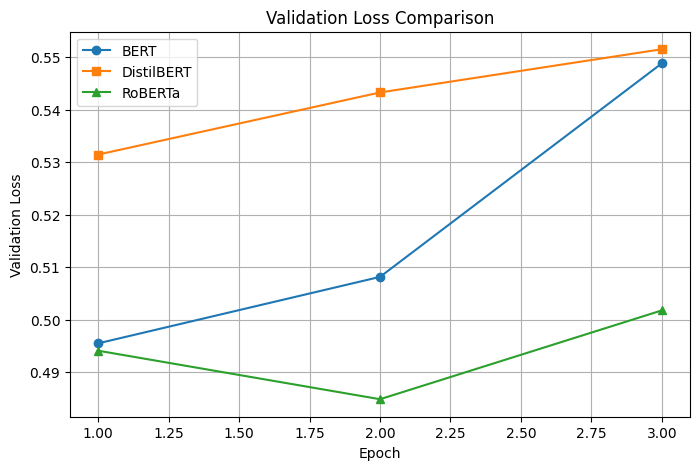

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    loss_df_bert["Epoch"],
    loss_df_bert["Validation Loss"],
    marker='o',
    label="BERT"
)

plt.plot(
    loss_df_distilbert["Epoch"],
    loss_df_distilbert["Validation Loss"],
    marker='s',
    label="DistilBERT"
)

plt.plot(
    loss_df_roberta["Epoch"],
    loss_df_roberta["Validation Loss"],
    marker='^',
    label="RoBERTa"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

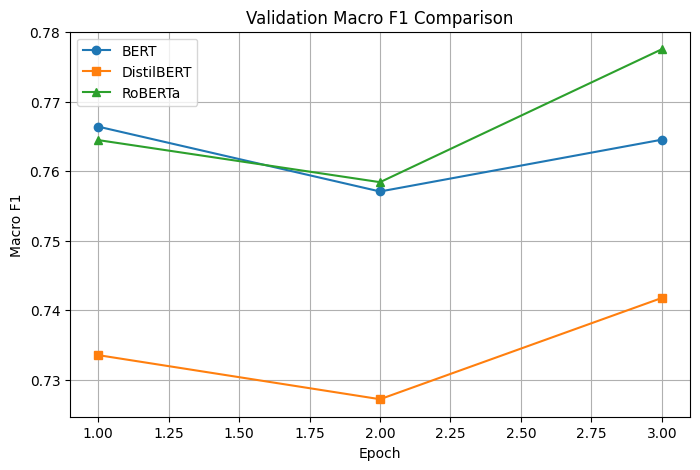

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    f1_df_bert["Epoch"],
    f1_df_bert["Validation Macro F1"],
    marker='o',
    label="BERT"
)

plt.plot(
    f1_df_distilbert["Epoch"],
    f1_df_distilbert["Validation Macro F1"],
    marker='s',
    label="DistilBERT"
)

plt.plot(
    f1_df_roberta["Epoch"],
    f1_df_roberta["Validation Macro F1"],
    marker='^',
    label="RoBERTa"
)

plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1 Comparison")
plt.legend()
plt.grid(True)

plt.show()

## **FINAL ROBERTA MODEL TRAINING** - Without adjustments

In [ ]:
final_train_df = pd.concat([train_df, val_df]).reset_index(drop=True)

print(final_train_df.shape)

(6087, 3)


In [ ]:
from datasets import Dataset

final_train_dataset = Dataset.from_pandas(
    final_train_df[["Combined_Text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["Combined_Text", "label"]]
)

In [ ]:
from transformers import AutoTokenizer

RoBERTa_MODEL_NAME = "roberta-base"
roberta_tokenizer = AutoTokenizer.from_pretrained(RoBERTa_MODEL_NAME)

def roberta_tokenize(batch):
    return roberta_tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
final_train_tokenized = final_train_dataset.map(roberta_tokenize, batched=True)
test_tokenized = test_dataset.map(roberta_tokenize, batched=True)

Map:   0%|          | 0/6087 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

final_model = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

final_training_args = TrainingArguments(
    output_dir="/content/RoBERTa_Final_Model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42
)

In [ ]:
from transformers import Trainer

final_trainer = Trainer(
    model=final_model,
    args=final_training_args,
    train_dataset=final_train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
final_trainer.train()

Step,Training Loss
50,0.931749
100,0.761416
150,0.629235
200,0.570476
250,0.555975
300,0.606549
350,0.510987
400,0.512885
450,0.426011
500,0.384091


TrainOutput(global_step=1143, training_loss=0.47067543673911644, metrics={'train_runtime': 454.8685, 'train_samples_per_second': 40.146, 'train_steps_per_second': 2.513, 'total_flos': 1201178530282752.0, 'train_loss': 0.47067543673911644, 'epoch': 3.0})

In [ ]:
test_results = final_trainer.evaluate(test_tokenized)
print(test_results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.343267,0.553119,1143,0.804651,0.781904,0.765181,0.770705


{'eval_loss': 0.5531191229820251, 'eval_accuracy': 0.8046511627906977, 'eval_precision': 0.7819040048362927, 'eval_recall': 0.7651813565581973, 'eval_f1': 0.7707049154417575}


In [ ]:
predictions = final_trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.78      0.77      0.77       172
     Neutral       0.72      0.59      0.65       325
    Positive       0.85      0.93      0.89       578

    accuracy                           0.80      1075
   macro avg       0.78      0.77      0.77      1075
weighted avg       0.80      0.80      0.80      1075



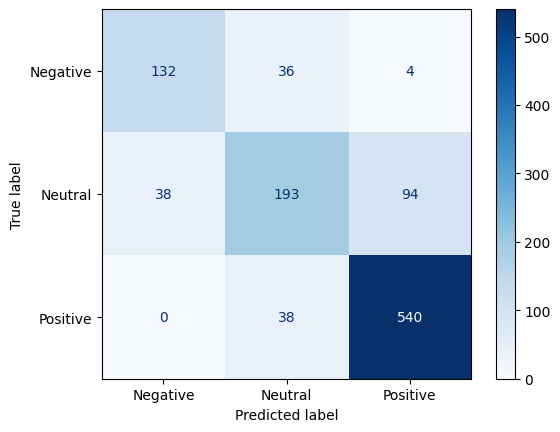

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [ ]:
final_trainer.save_model("/content/RoBERTa_FINAL_MODEL")
roberta_tokenizer.save_pretrained("/content/RoBERTa_FINAL_MODEL")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_FINAL_MODEL/tokenizer_config.json',
 '/content/RoBERTa_FINAL_MODEL/tokenizer.json')

In [ ]:
!zip -r RoBERTa_FINAL_MODEL.zip /content/RoBERTa_FINAL_MODEL

updating: content/RoBERTa_FINAL_MODEL/ (stored 0%)
updating: content/RoBERTa_FINAL_MODEL/config.json (deflated 53%)
updating: content/RoBERTa_FINAL_MODEL/training_args.bin (deflated 53%)
updating: content/RoBERTa_FINAL_MODEL/tokenizer_config.json (deflated 51%)
updating: content/RoBERTa_FINAL_MODEL/tokenizer.json (deflated 82%)
updating: content/RoBERTa_FINAL_MODEL/model.safetensors (deflated 12%)


In [ ]:
from google.colab import files
files.download("RoBERTa_FINAL_MODEL.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **FINAL ROBERTA MODEL TRAINING** - With Class Weights

In [ ]:
final_model_with_cw = AutoModelForSequenceClassification.from_pretrained(
    RoBERTa_MODEL_NAME,
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=final_train_df["label"]
)

print(class_weights)

[2.08530319 1.10271739 0.61973122]


In [ ]:
import torch

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [ ]:
from transformers import Trainer
import torch.nn as nn

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(model.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [ ]:
final_trainer_with_cw = WeightedLossTrainer(
    model=final_model_with_cw,
    args=final_training_args,
    train_dataset=final_train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [ ]:
final_trainer_with_cw.train()

Step,Training Loss
50,0.489391
100,0.430485
150,0.365063
200,0.315998
250,0.261980
300,0.329346
350,0.287851
400,0.268497
450,0.162247
500,0.151660


TrainOutput(global_step=1143, training_loss=0.241561883390732, metrics={'train_runtime': 455.2248, 'train_samples_per_second': 40.114, 'train_steps_per_second': 2.511, 'total_flos': 1201178530282752.0, 'train_loss': 0.241561883390732, 'epoch': 3.0})

In [ ]:
test_results = final_trainer_with_cw.evaluate(test_tokenized)
print(test_results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.180455,1.092660,1143,0.787907,0.748759,0.752035,0.749876


{'eval_loss': 1.0926597118377686, 'eval_accuracy': 0.7879069767441861, 'eval_precision': 0.7487594186725927, 'eval_recall': 0.7520347753960049, 'eval_f1': 0.7498760246923121}


In [ ]:
predictions = final_trainer_with_cw.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.70      0.74      0.72       172
     Neutral       0.67      0.62      0.65       325
    Positive       0.87      0.90      0.88       578

    accuracy                           0.79      1075
   macro avg       0.75      0.75      0.75      1075
weighted avg       0.78      0.79      0.79      1075



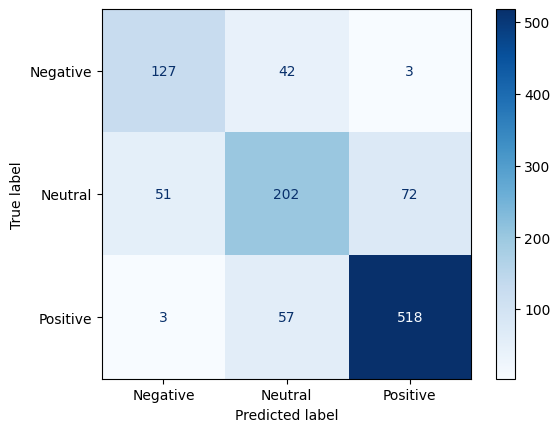

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

## **FINAL ROBERTA MODEL TRAINING** - With ROS

In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X = final_train_df["Combined_Text"].values.reshape(-1, 1)
y = final_train_df["label"]

X_res, y_res = ros.fit_resample(X, y)

print("Before:", np.bincount(y))
print("After:", np.bincount(y_res))

Before: [ 973 1840 3274]
After: [3274 3274 3274]


In [ ]:
balanced_train_df = pd.DataFrame({
    "Combined_Text": X_res.flatten(),
    "label": y_res
}).reset_index(drop=True)

In [ ]:
from datasets import Dataset

final_train_dataset = Dataset.from_pandas(balanced_train_df)
test_dataset = Dataset.from_pandas(test_df[["Combined_Text", "label"]])

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["Combined_Text"],
        truncation=True,
        padding=True,
        max_length=128
    )

In [ ]:
train_tokenized = final_train_dataset.map(tokenize, batched=True)
test_tokenized = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/9822 [00:00<?, ? examples/s]

Map:   0%|          | 0/1075 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/RoBERTa_ROS",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Step,Training Loss
50,1.050189
100,0.681665
150,0.586567
200,0.595043
250,0.609831
300,0.538225
350,0.572618
400,0.471224
450,0.520177
500,0.467631


TrainOutput(global_step=1842, training_loss=0.35948596326846644, metrics={'train_runtime': 735.6244, 'train_samples_per_second': 40.056, 'train_steps_per_second': 2.504, 'total_flos': 1938224991693312.0, 'train_loss': 0.35948596326846644, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate(test_tokenized)
print(results)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.136197,0.788228,1842,0.796279,0.762542,0.757688,0.759120


{'eval_loss': 0.7882281541824341, 'eval_accuracy': 0.7962790697674419, 'eval_precision': 0.7625424044653965, 'eval_recall': 0.7576884905282748, 'eval_f1': 0.7591197515449811}


In [ ]:
predictions = trainer.predict(test_tokenized)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.73      0.74      0.74       172
     Neutral       0.69      0.62      0.65       325
    Positive       0.86      0.91      0.89       578

    accuracy                           0.80      1075
   macro avg       0.76      0.76      0.76      1075
weighted avg       0.79      0.80      0.79      1075



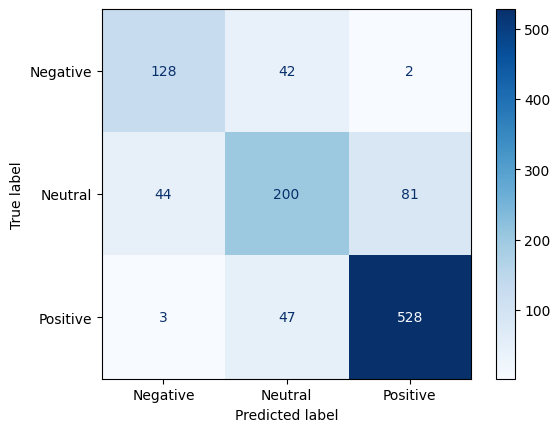

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

## **Best Model Saving**

In [ ]:
trainer.save_model("/content/RoBERTa_FINAL_MODEL_ROS")
tokenizer.save_pretrained("/content/RoBERTa_FINAL_MODEL_ROS")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/RoBERTa_FINAL_MODEL_ROS/tokenizer_config.json',
 '/content/RoBERTa_FINAL_MODEL_ROS/tokenizer.json')

In [ ]:
!zip -r RoBERTa_FINAL_MODEL_ROS.zip /content/RoBERTa_FINAL_MODEL_ROS

  adding: content/RoBERTa_FINAL_MODEL_ROS/ (stored 0%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/config.json (deflated 53%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/training_args.bin (deflated 53%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/tokenizer_config.json (deflated 51%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/tokenizer.json (deflated 82%)
  adding: content/RoBERTa_FINAL_MODEL_ROS/model.safetensors (deflated 12%)


In [ ]:
from google.colab import files
files.download("RoBERTa_FINAL_MODEL_ROS.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

input_file = "/content/drive/MyDrive/Colab Notebooks/F_Sentiment Prediction Model_6_2.ipynb"
output_file = "/content/drive/MyDrive/Colab Notebooks/F_Sentiment Prediction Model_6_2.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = json.load(f)

# Remove broken widget metadata
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(nb, f, indent=1)

print("Clean notebook saved for GitHub:", output_file)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/F_Sentiment Prediction Model_6_2.ipynb'